# Introduction

Methodology and sources

### Polling data workflow

1. Central Bureau of Statistics (CBS) assigns a polling area (אזור קלפי) to polling station. A polling area is always contained within a statistical area (אזור סטטיסטי). Polling areas are not open for the public since the data is too granular to rule out identification of voters (it contains mapping of each polling station to the streets and house numbers of the few hundred voters assigned to it, which in some cases may all live in one building). Instead, the CBS publishes a mapping between polling stations and statistical areas, so several polling stations can be mapped to one statistical area. 

2. The Central Elections Committee uses the CBS file to publish an initial assignment of citizens to polling stations and polling centers ("Aleph", טופס א), allowing the public to check the address of their center and apply for changes.

3. At a second phase, changes and finetuning in polling centers' locations result in the final map of polling stations to polling centers ("Bet", טופס ב). The polling station IDs are still the original ones first prepared by the CBS, and therefore can be linked to the CBS mapping to statistical areas. (Voters who changed their address in the meantime will be, however, falsely represented in their original statistical area.)

4. Finally, station balancing (איזון קלפיות) takes place and balanced polling stations change their ID and acquire a digit after the decimal point (for an explanation on how balancing works, see below). The new IDs are the final ones and can be linked to the election results published by the Committee. The result of the balancing appears as a second version of Bet ("Bet after balancing") with the new column "static_id" (ברזל), a unique identifier of a polling station (numbering of all stations from north to south). Although the polling station ID might change, the polling center ID remains as in the original Bet ("Bet before balancing"). In a balanced center, it can be used to link the two files. 


In [201]:
import math
import sqlite3
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely import wkt
from IPython.display import display

In [202]:
conn = sqlite3.connect(':memory:')

# Load raw data

## Bet before balancing
Station to center. Source: Central Elections Committee

In [237]:
bet_pre_balancing = {}
for election in [21, 22, 23]:
    with open(f'C:/Itay/Data/elections/input_files/bet_pre_balancing_{election}.csv', 'r', encoding='hebrew') as f:
        bet_pre_balancing[election] = pd.read_csv(f)

In [238]:
for election in [21, 22, 23]:
    display(bet_pre_balancing[election].head(3))

,סמל ועדה,שם ועדה,סמל גוש ישובים,שם גוש ישובים,סמל ישוב בחירות,שם ישוב בחירות,סמל גוש ריכוזים,שם גוש ריכוזים,סמל קלפי,סמל רכוז,...,בוחרי כנסת בפועל,סוג פיצול,מאות,ממספר,צורפ ל-,מחוז,מס' ברזל,מס' קלסר,סמל קלפי אם,מס' קלפיות אחורי איזון
0,1,ירושלים,0,NaN,3000,ירושלים,1,רעיה הרבסטמן,1.0,14,...,689,NaN,NaN,NaN,NaN,ים,0,0,0.0,0
1,1,ירושלים,0,NaN,3000,ירושלים,1,רעיה הרבסטמן,2.0,414,...,663,NaN,NaN,NaN,NaN,ים,0,0,0.0,0
2,1,ירושלים,0,NaN,3000,ירושלים,2,רמי בן דויד,3.0,18,...,700,NaN,NaN,NaN,NaN,ים,0,0,0.0,0


,סמל ועדה,שם ועדה,סמל גוש ישובים,שם גוש ישובים,סמל ישוב בחירות,שם ישוב בחירות,סמל גוש ריכוזים,שם גוש ריכוזים,סמל קלפי,סמל רכוז,...,בוחרי כנסת בפועל,סוג פיצול,מאות,ממספר,צורפ ל-,מחוז,מס' ברזל,מס' קלסר,סמל קלפי אם,מס' קלפיות אחורי איזון
0,1,ירושלים,0,NaN,3000,ירושלים,2,רעיה-אלירן,1.0,14,...,699,NaN,NaN,NaN,NaN,ים,0,0,0.0,0
1,1,ירושלים,0,NaN,3000,ירושלים,3,רעיה-יוני,2.0,414,...,667,NaN,NaN,NaN,NaN,ים,0,0,0.0,0
2,1,ירושלים,0,NaN,3000,ירושלים,8,ציון-עופר,3.0,18,...,699,NaN,NaN,NaN,NaN,ים,0,0,0.0,0


,סמל ועדה,שם ועדה,סמל גוש ישובים,שם גוש ישובים,סמל ישוב בחירות,שם ישוב בחירות,סמל גוש ריכוזים,שם גוש ריכוזים,סמל קלפי,סמל רכוז,...,בוחרי כנסת בפועל,סוג פיצול,מאות,ממספר,צורפ ל-,מחוז,מס' ברזל,מס' קלסר,סמל קלפי אם,מס' קלפיות אחורי איזון
0,1,ירושלים,0,NaN,3000,ירושלים,2,רעיה - רונן,1.0,14,...,713,NaN,NaN,NaN,NaN,ים,0,0,0.0,0
1,1,ירושלים,0,NaN,3000,ירושלים,3,רעיה - יאיר,2.0,414,...,675,NaN,NaN,NaN,NaN,ים,0,0,0.0,0
2,1,ירושלים,0,NaN,3000,ירושלים,8,ציון-עופר,3.0,18,...,690,NaN,NaN,NaN,NaN,ים,0,0,0.0,0


In [239]:
# drop unnecessary columns and set latin names
# ces_stat_id is the stat_id from the Central Elections Committee
drop_cols = ['סמל ועדה' ,'שם ועדה' ,'סמל גוש ישובים' ,'שם גוש ישובים' ,'סמל גוש ריכוזים' ,'שם גוש ריכוזים' ,'נגישה' ,'נגישה מיוחדת' ,'הדפסה בערבית']
for election in [21, 22, 23]:
    bet_pre_balancing[election].drop(drop_cols, axis=1, inplace=True)
    bet_pre_balancing[election].drop(bet_pre_balancing[election].columns[12:], axis=1, inplace=True)
    bet_pre_balancing[election].columns = ['city_id', 'city_name', 'station_id', 'center_id', 'station_address', 'station_desc', 
                 'ces_stat_id', 'pop', 'voters', 'jewish_voters', 'jewish_pop', 'actual_voters']

In [240]:
# city_center_id: city_id and center_id concatenated
for election in [21, 22, 23]:
    bet_pre_balancing[election]['city_center_id'] = bet_pre_balancing[election]['city_id'].astype(str) + '/' + \
        bet_pre_balancing[election]['center_id'].astype(str)

## CBS mapping
Station to stat. Source: Central Bureau of Statistics

In [241]:
cbs_mapping = {}
for election in [21, 22, 23]:
    with open(f'C:/Itay/Data/elections/input_files/cbs_mapping_{election}.csv', 'r', encoding='hebrew') as f:
        cbs_mapping[election] = pd.read_csv(f)

In [242]:
for election in [21, 22, 23]:
    display(cbs_mapping[election].head(3))

,semel_yishuv,shem_yishuv,kalpi2019,stat2011,yishuv_stat2011
0,70,אשדוד,164,316,700316
1,70,אשדוד,165,315,700315
2,70,אשדוד,166,316,700316


,semel_yishuv,shem_yishuv,kalpi2019,stat2011,yishuv_stat2011
0,3000,ירושלים,50,832,30000832
1,3000,ירושלים,51,832,30000832
2,3000,ירושלים,52,834,30000834


,semel_yishuv,shem_yishuv,kalpi2019,stat2011,yishuv_stat2011
0,3000,ירושלים,1,515,30000515
1,3000,ירושלים,2,824,30000824
2,3000,ירושלים,3,824,30000824


In [243]:
for election in [21, 22, 23]:
    cbs_mapping[election].drop(['yishuv_stat2011'], axis=1, inplace=True)
    cbs_mapping[election].columns = ['city_id', 'cbs_city_name', 'station_id', 'cbs_stat_id']

### stat_id cleanup
Statistics:

In [244]:
for election in [21, 22, 23]:
    print(f'\n== Election {election} ==\n')
    joined_ces_cbs = bet_pre_balancing[election].set_index(['city_id', 'station_id']) \
             .join(cbs_mapping[election].set_index(['city_id', 'station_id']), how='left')
    
    ces_has_cbs_has_similar = joined_ces_cbs[(joined_ces_cbs.ces_stat_id.notnull() & joined_ces_cbs.cbs_stat_id.notnull() & (joined_ces_cbs.ces_stat_id==joined_ces_cbs.cbs_stat_id))]
    ces_has_cbs_has_diff = joined_ces_cbs[(joined_ces_cbs.ces_stat_id.notnull() & joined_ces_cbs.cbs_stat_id.notnull() & (joined_ces_cbs.ces_stat_id!=joined_ces_cbs.cbs_stat_id))]
    ces_has_cbs_not = joined_ces_cbs[(joined_ces_cbs.ces_stat_id.notnull() & joined_ces_cbs.cbs_stat_id.isnull())]
    ces_not_cbs_has = joined_ces_cbs[(joined_ces_cbs.ces_stat_id.isnull() & joined_ces_cbs.cbs_stat_id.notnull())]
    ces_not_cbs_not = joined_ces_cbs[(joined_ces_cbs.ces_stat_id.isnull() & joined_ces_cbs.cbs_stat_id.isnull())]
    
    print(f'CES and CBS agree on stat_id in {ces_has_cbs_has_similar["city_name"].count() + ces_not_cbs_not["city_name"].count()} cases: {ces_has_cbs_has_similar["city_name"].count()} same value and {ces_not_cbs_not["city_name"].count()} both empty')
    print(f'They mismatch in {ces_has_cbs_has_diff["city_name"].count() + ces_has_cbs_not["city_name"].count() + ces_not_cbs_has["city_name"].count()} cases:')
    print(f'{ces_has_cbs_has_diff["city_name"].count()} cases of value mismatch -')
    display(ces_has_cbs_has_diff.head(5))
    print(f'{ces_has_cbs_not["city_name"].count()} cases where CES has stat_id and CBS not -')
    display(ces_has_cbs_not.head(5))
    print('By city:')
    display(pd.DataFrame(ces_has_cbs_not.groupby('city_name')['ces_stat_id'].count()))
    print(f'{ces_not_cbs_has["city_name"].count()} cases where CES has no stat_id and CBS does -')
    display(ces_not_cbs_has.head(5))
    print('By stat_id:')
    display(pd.DataFrame(ces_not_cbs_has.groupby('cbs_stat_id')['cbs_city_name'].count()))


== Election 21 ==

CES and CBS agree on stat_id in 8928 cases: 8160 same value and 768 both empty
They mismatch in 1927 cases:
0 cases of value mismatch -


,,city_name,center_id,station_address,station_desc,ces_stat_id,pop,voters,jewish_voters,jewish_pop,actual_voters,city_center_id,cbs_city_name,cbs_stat_id
city_id,station_id,,,,,,,,,,,,,


3 cases where CES has stat_id and CBS not -


,,city_name,center_id,station_address,station_desc,ces_stat_id,pop,voters,jewish_voters,jewish_pop,actual_voters,city_center_id,cbs_city_name,cbs_stat_id
city_id,station_id,,,,,,,,,,,,,
3000,33.0,ירושלים,44,"מן,7","ישיבת נעם (לשעבר בי""ס דרור)",1031.0,274,200,193,266,200,3000/44,NaN,NaN
2710,56.0,אום אל-פחם,4,שכ עין אלנבי,"בי""ס אלאקווס",15.0,958,574,0,0,574,2710/4,NaN,NaN
1192,9.0,ערערה-בנגב,8,ערערה-בנגב,"ביה""ס יסודי אלראזי",3.0,"1,286",686,0,0,686,1192/8,NaN,NaN


By city:


...

,ces_stat_id
city_name,
אום אל-פחם,55
דאלית אל-כרמל,19


1956 cases where CES has no stat_id and CBS does -


city_name  center_id     station_address  \
city_id station_id                                                      
1056    1.0         עין כרם-בי"ס חקלאי          1  עין כרם-בי"ס חקלאי   
127     1.0                    רמת רחל          1             רמת רחל   
472     1.0                    אבו גוש          1          אל רשיד,1    
        2.0                    אבו גוש          1          אל רשיד,1    
        3.0                    אבו גוש          2           דרך השלום   

                               station_desc  ces_stat_id    pop  voters  \
city_id station_id                                                        
1056    1.0                         מזכירות          NaN     27      19   
127     1.0                    מועדון חברים          NaN    553     354   
472     1.0         בית ספר יסודי אבו - גוש          NaN    981     530   
        2.0         בית ספר יסודי אבו - גוש          NaN  1,209     693   
        3.0               בי"ס חטיבת ביניים          NaN    923     585   

                    jewish_voters jewish_pop  actual_voters city_center_id  \
city_id station_id                                                           
1056    1.0                    19         27             19         1056/1   
127     1.0                   347        539            354          127/1   
472     1.0                     4          5            530          472/1   
        2.0                    17         19            693          472/1   
        3.0                     3          3            585          472/2   

                         cbs_city_name  cbs_stat_id  
city_id station_id                                   
1056    1.0         עין כרם-בי"ס חקלאי          1.0  
127     1.0                    רמת רחל          1.0  
472     1.0                    אבו גוש          1.0  
        2.0                    אבו גוש          1.0  
        3.0                    אבו גוש          1.0

By stat_id:


,cbs_city_name
cbs_stat_id,
1.0,1956


**Conclusions and strategy:**

There are only 3 cases of stat_id value mismatch between CES and CBS, in election 23; we'll take CES data.  
There are 3 and 1 cases (in elections 21 and 22 respectively) where CES has stat_id and CBS doesn't. However, in election 23 there are 74 such cases in two specific cities. We'll keep CES data but need to ask CBS why these stat_id's are missing (these two cities had CBS data in elections 21 and 22).  
In all cases where CES have not stat_id data and CBS does (about 1,900 each election), it is stat_id 1.0, and therefore we'll use CBS data.

In [245]:
for election in [21, 22, 23]:
    # join CES and CBS
    bet_pre_balancing[election] = bet_pre_balancing[election].set_index(['city_id', 'station_id']) \
             .join(cbs_mapping[election].set_index(['city_id', 'station_id'])['cbs_stat_id'], how='left') \
             .reset_index()
    # stat_id is ces_stat_id unless ces_stat_id is missing and cbs_stat_id not
    bet_pre_balancing[election]['stat_id'] = bet_pre_balancing[election].ces_stat_id.combine_first(bet_pre_balancing[election].cbs_stat_id)
    # drop separate stat_ids
    bet_pre_balancing[election].drop(columns=['ces_stat_id', 'cbs_stat_id'], inplace=True)
    # create city_stat_id
    bet_pre_balancing[election]['city_stat_id'] = bet_pre_balancing[election].city_id.astype(str) + '/' + bet_pre_balancing[election].stat_id.astype(str)

In [246]:
bet_pre_balancing[21].head(5)

,city_id,station_id,city_name,center_id,station_address,station_desc,pop,voters,jewish_voters,jewish_pop,actual_voters,city_center_id,stat_id,city_stat_id
0,3000,1.0,ירושלים,14,"מעגלי הרי""ם לוין,27","ביה""ס בית יעקב הצפון (סנהדריה)","1,271",689,686,"1,266",689,3000/14,515.0,3000/515.0
1,3000,2.0,ירושלים,414,"שמואל הנביא,85","ת""ת שערי תורה (למען אחי)","1,335",663,659,"1,331",663,3000/414,824.0,3000/824.0
2,3000,3.0,ירושלים,18,"מגן האלף,1",סמינר בית יעקב - עטרת חן,"1,413",700,699,"1,408",700,3000/18,824.0,3000/824.0
3,3000,4.0,ירושלים,59,"פישל אהרן,29","ת""ת זיכרו תורת משה","1,612",768,767,"1,605",768,3000/59,824.0,3000/824.0
4,3000,5.0,ירושלים,383,"שבטי ישראל,27",משרד החינוך,"1,244",527,527,"1,244",527,3000/383,821.0,3000/821.0


## Bet final
Station to center after balancing. Source: Central Elections Committee

In [247]:
bet_final = {}
for election in [21, 22, 23]:
    with open(f'C:/Itay/Data/elections/input_files/bet_final_{election}.csv', 'r', encoding='hebrew') as f:
        bet_final[election] = pd.read_csv(f)

In [248]:
for election in [21, 22, 23]:
    display(bet_final[election].head(3))

,סמל ועדה,שם ועדה,סמל ישוב בחירות,שם ישוב בחירות,סמל קלפי,סמל רכוז,כתובת קלפי,מקום קלפי,נגישה מיוחדת,נגישה,הדפסה בערבית,בוחרי כנסת בפועל,מס' ברזל
0,1,ירושלים,3000,ירושלים,5.0,383,"שבטי ישראל,27",משרד החינוך,,,,527,1.0
1,1,ירושלים,3000,ירושלים,7.0,75,"נטר,40","בי""ס יסודי בית מרגלית",,,,621,2.0
2,1,ירושלים,3000,ירושלים,11.0,83,"שמעון הצדיק,23","בי""ס חב""ד בית חנה",,,,557,3.0


,סמל ועדה,שם ועדה,סמל ישוב בחירות,שם ישוב בחירות,סמל קלפי,סמל רכוז,כתובת קלפי,מקום קלפי,נגישה,נגישה מיוחדת,הדפסה בערבית,בוחרי כנסת בפועל,סוג פיצול,מס' ברזל
0,1,ירושלים,3000,ירושלים,423.0,261,"תמיר שמואל,74","בי""ס ממלכתי ע""ש מרדכי איש-שלום",כ,כ,,431,NaN,1
1,1,ירושלים,3000,ירושלים,530.0,23,"לוחמי הגטאות,7",אולפנת צביה יצירתית,,,,695,NaN,2
2,1,ירושלים,3000,ירושלים,560.0,23,"לוחמי הגטאות,7",אולפנת צביה יצירתית,,,,577,NaN,3


,מס' ברזל,סמל ועדה,שם ועדה,סמל גוש ישובים,שם גוש ישובים,סמל ישוב בחירות,שם ישוב בחירות,סמל גוש ריכוזים,שם גוש ריכוזים,סמל קלפי,...,אוכלוסיה,בוחרי כנסת,בוחרי כנסת יהודים,אוכלוסיה יהודים,בוחרי כנסת בפועל,סוג פיצול,מאות,ממספר,צורפ ל-,מס' קלסר
0,1,1,ירושלים,0,NaN,3000,ירושלים,1,רעיה - אילנית,392.1,...,0,690,678,0,690,איזון קלפיות,NaN,NaN,NaN,1
1,2,1,ירושלים,0,NaN,3000,ירושלים,1,רעיה - אילנית,392.2,...,0,690,682,0,690,איזון קלפיות,NaN,NaN,NaN,1
2,3,1,ירושלים,0,NaN,3000,ירושלים,1,רעיה - אילנית,392.3,...,0,689,679,0,689,איזון קלפיות,NaN,NaN,NaN,1


In [249]:
# drop unnecessary columns and bring all tables to a similar format
bet_final[21].drop(columns=bet_final[21].columns[[0, 1, 8, 9, 10]], inplace=True)
bet_final[22].drop(columns=bet_final[22].columns[[0, 1, 8, 9, 10]], inplace=True)
bet_final[23].drop(columns=bet_final[23].columns[[1, 2, 3, 4, 7, 8, 13, 14, 15, 16, 23, 24, 25, 26]], inplace=True)

bet_final[21].columns = ['city_id', 'city_name', 'station_id', 'center_id', 'station_address', 'station_desc', 'actual_voters', 'static_id']
bet_final[21].insert(6, 'pop', np.nan)
bet_final[21].insert(7, 'voters', np.nan)
bet_final[21].insert(8, 'jewish_voters', np.nan)
bet_final[21].insert(9, 'jewish_pop', np.nan)
bet_final[21].insert(11, 'split_type', np.nan)

bet_final[22].columns = ['city_id', 'city_name', 'station_id', 'center_id', 'station_address', 'station_desc', 'actual_voters', 'split_type', 'static_id']
bet_final[22].insert(6, 'pop', np.nan)
bet_final[22].insert(7, 'voters', np.nan)
bet_final[22].insert(8, 'jewish_voters', np.nan)
bet_final[22].insert(9, 'jewish_pop', np.nan)

bet_final[23].columns = ['static_id', 'city_id', 'city_name', 'station_id', 'center_id', 'station_address', 'station_desc', 'pop', 'voters', 'jewish_voters', 'jewish_pop', 'actual_voters', 'split_type']
bet_final[23] = bet_final[23][['city_id', 'city_name', 'station_id', 'center_id', 'station_address', 'station_desc', 'pop', 'voters', 'jewish_voters', 'jewish_pop', 'actual_voters', 'split_type', 'static_id']]

In [250]:
# city_center_id: city_id and center_id concatenated
for election in [21, 22, 23]:
    bet_final[election]['city_center_id'] = bet_final[election]['city_id'].astype(str) + '/' + \
        bet_final[election]['center_id'].astype(str)

In [251]:
print('Types of station splits:')
for election in [21, 22, 23]:
    print(f'\n== Election {election} ==\n')
    display(bet_final[election].groupby('split_type').count()[['station_id', 'center_id']])

Types of station splits:

== Election 21 ==



,station_id,center_id
split_type,,



== Election 22 ==



,station_id,center_id
split_type,,
אות ראשונה בשם משפחה,18,18
איזון קלפיות,1703,1703
לפי מספר סידורי,4,4



== Election 23 ==



,station_id,center_id
split_type,,
אות ראשונה בשם משפחה,14,14
איזון קלפיות,1570,1570


In all split cases (i.e. change in the voters list of a station), the new station_id (in Bet) got a digit after the decimal point. Round station_id's in Bet mean direct mapping to the station_id's in Aleph. Non-round id's require processing:

In case of balancing (`איזון קלפיות`), stat_id's need to merge (see below). In both other cases (`אות ראשונה בשם משפחה`,`לפי מספר סידורי`) a single station was split into two. In order to match these cases to the station_id's in the CBS mapping (now joined into Aleph), they just need to be floored, i.e. the the join should ignore the digits after the decimal point.

Since the data for election 21 is missing we will treat all float station IDs as a balancing case.

In [252]:
bet_final[21].loc[(np.floor(bet_final[21]['station_id'])!=bet_final[21]['station_id']), 'split_type'] = 'איזון קלפיות'
for election in [21, 22, 23]:
    bet_final[election].loc[bet_final[election].split_type=='איזון קלפיות', 'split_type'] = 'balancing'
    bet_final[election].loc[bet_final[election].split_type.isin(['אות ראשונה בשם משפחה', 'לפי מספר סידורי']), 'split_type'] = 'other'

Differences between Bet before and after balancing (i.e. originally planned vs. final stations):

In [253]:
print('Final stations missing from pre_balancing by split_type:')
for election in [21, 22, 23]:
    print(f'\n== Election {election} ==\n')
    joined_bet = bet_pre_balancing[election][['city_id', 'station_id', 'actual_voters']].set_index(['city_id', 'station_id']) \
        .join(bet_final[election][['city_id', 'station_id', 'actual_voters', 'split_type']].set_index(['city_id', 'station_id']),
             how='outer', lsuffix='_pre', rsuffix='_final')
    
    display(joined_bet[joined_bet.actual_voters_pre.isnull()] \
               .reset_index() \
               .fillna(value={'split_type': 'no_split'}) \
               .groupby('split_type').count())

Final stations missing from pre_balancing by split_type:

== Election 21 ==



,city_id,station_id,actual_voters_pre,actual_voters_final
split_type,,,,
balancing,1563,1563,0,1563



== Election 22 ==



,city_id,station_id,actual_voters_pre,actual_voters_final
split_type,,,,
balancing,1703,1703,0,1703
other,22,22,0,22



== Election 23 ==



,city_id,station_id,actual_voters_pre,actual_voters_final
split_type,,,,
balancing,1570,1570,0,1570
other,14,14,0,14


## Results
station to election results. Source: Central Elections Committee

In [254]:
results = {}
for election in [21, 22]:
    with open(f'C:/Itay/Data/elections/input_files/results_{election}.csv', 'r', encoding='hebrew') as f:
        results[election] = pd.read_csv(f)

In [255]:
for election in [21, 22]:
    display(results[election].head(5))

,שם ישוב,סמל ישוב,מספר קלפי,בזב,מצביעים,פסולים,כשרים,אמת,ג,דעם,...,צק,ץ,ץז,ץי,ק,קי,קן,קף,ר,שס
0,אבו ג'ווייעד (שבט),967,1.0,546,64,2,62,2,0,31,...,0,0,0,0,0,0,1,0,0,0
1,אבו ג'ווייעד (שבט),967,2.0,739,113,2,111,2,0,69,...,0,0,0,0,0,2,0,0,0,0
2,אבו ג'ווייעד (שבט),967,3.0,630,98,1,97,1,0,75,...,0,0,0,0,0,0,0,0,0,0
3,אבו גוש,472,1.0,518,197,6,191,4,0,36,...,0,1,0,0,1,0,0,0,0,1
4,אבו גוש,472,2.0,679,290,3,287,7,0,69,...,0,0,0,0,0,0,0,1,0,2


,סמל ועדה,ברזל,שם ישוב,סמל ישוב,קלפי,ריכוז,שופט,בזב,מצביעים,פסולים,...,פה,ףז,צ,צן,ץ,ק,קך,קץ,רק,שס
0,18,9797,אבו ג'ווייעד (שבט),967,1.0,1,0,559,113,2,...,9,0,0,0,0,1,0,0,0,0
1,18,9798,אבו ג'ווייעד (שבט),967,2.0,1,0,751,224,1,...,12,0,0,0,0,1,1,0,0,0
2,18,9799,אבו ג'ווייעד (שבט),967,3.0,1,0,651,205,6,...,1,0,0,0,0,1,0,0,0,0
3,2,733,אבו גוש,472,1.0,1,0,525,268,3,...,25,0,1,0,0,0,0,0,0,5
4,2,734,אבו גוש,472,2.0,1,0,686,363,6,...,33,0,0,0,0,2,1,0,0,6


In [256]:
# clean tables
results[21].rename(columns={'שם ישוב': 'city_name', 'סמל ישוב': 'city_id', 'מספר קלפי': 'station_id', 'בזב': 'bzb', 'מצביעים': 'voters', 'פסולים': 'invalid', 'כשרים': 'kosher'}, inplace=True)
results[22].drop(columns=['סמל ועדה', 'שופט'], inplace=True)
results[22].rename(columns={'שם ישוב': 'city_name', 'סמל ישוב': 'city_id', 'קלפי': 'station_id', 'בזב': 'bzb', 'מצביעים': 'voters', 'פסולים': 'invalid', 'כשרים': 'kosher', 'ריכוז': 'center_id', 'ברזל': 'static_id'}, inplace=True)
results[21].insert(0, 'static_id', np.nan)
results[21].insert(4, 'center_id', np.nan)

Differences between Bet and results (i.e. planned stations vs. actual):

In [257]:
for election in [21, 22]:
    joined_results_bet = results[election][['city_id', 'station_id', 'voters']].set_index(['city_id', 'station_id']) \
    .join(bet_final[election][['city_id', 'station_id', 'actual_voters']].set_index(['city_id', 'station_id']),
         how='outer', lsuffix='_results', rsuffix='_bet')
    
    print('Planned stations (Bet) that do not appear in the results file:')
    display(joined_results_bet[joined_results_bet.voters.isnull()])

    print('Actual stations (results) that do not appear in the planning (Bet):')
    display(joined_results_bet[joined_results_bet.actual_voters.isnull()].groupby('city_id').count())

Planned stations (Bet) that do not appear in the results file:


,,voters,actual_voters
city_id,station_id,,


Actual stations (results) that do not appear in the planning (Bet):


,voters,actual_voters
city_id,,
99999,305,0


Planned stations (Bet) that do not appear in the results file:


voters  actual_voters
city_id station_id                       
502     2.0            NaN          670.0
        14.0           NaN          740.0
        15.0           NaN          661.0
7500    12.0           NaN          741.0

Actual stations (results) that do not appear in the planning (Bet):


,voters,actual_voters
city_id,,
9999,362,0


Missing stations from cities 502 and 7500 (YIRKA and SAKHNIN) were not published due to suspected election fraud.  
city_id 9999 is external votes that appear in the results but not in the planning.

## Polygons
stats_geo is the geojson of the 2011 statistical areas, corrected to Israeli coordinates system and simplified to 5%. Source: Central Bureau of Statistics

In [258]:
with open('C:\Itay\Data\elections\Lamas_Census_Tracts_201_5pct_2020-01-29.json', 'rb') as f:
    stats_geo = gpd.read_file(f)

In [259]:
stats_geo.head(5)

,OBJECTID,SEMEL_YISH,STAT11,YISHUV_STA,SHEM_YISHU,SHEM_YIS_1,SHAPE_AREA,SHAPE_LEN,geometry
0,1,7,1,70001,שחר,SHAHAR,2.299739e+06,7467.179301,"POLYGON ((34.72065688305076 31.61269746742549,..."
1,2,10,1,100001,תירוש,TIROSH,1.336218e+06,5335.842301,"POLYGON ((34.88298771643932 31.74690273688246,..."
2,3,11,1,110001,ניר חן,NIR HEN,8.829797e+05,4696.853603,"POLYGON ((34.72065688305076 31.61269746742549,..."
3,4,13,1,130001,חצבה,HAZEVA,1.810467e+07,17968.666430,"POLYGON ((35.31487632766085 30.78011931860659,..."
4,5,15,1,150001,נועם,NO'AM,1.558277e+06,6883.605246,"POLYGON ((34.78798084795722 31.57617074081967,..."


Additional polygons missing from the 2011 file

In [260]:
# missing for unknown reason
with open('C:\Itay\Data\elections\\additional_cities\gv_Nave_Midbar_27_06_2018.json', 'rb') as f:
    additional = gpd.read_file(f)
extra_cities = additional[additional.P_CODE=='1375']

# new cities, predominantly for the settlers evacuated from the Gaza Strip
with open('C:\Itay\Data\elections\\additional_cities\gv_Gan rave_8_11_2016_plt.json', 'rb') as f:
    additional = gpd.read_file(f)
extra_cities = pd.concat([extra_cities, additional[additional.P_CODE=='1336']])

with open('C:\Itay\Data\elections\\additional_cities\gv_lahish_01_08_2018.json', 'rb') as f:
    additional = gpd.read_file(f)
extra_cities = pd.concat([extra_cities, additional[additional.P_CODE.isin(['1365', '1368', '1369', '1374'])]])

with open('C:\Itay\Data\elections\\additional_cities\gv_Hof_ashkelon_18_07_2018.json', 'rb') as f:
    additional = gpd.read_file(f)
extra_cities = pd.concat([extra_cities, additional[additional.P_CODE.isin(['1376'])]])

with open('C:\Itay\Data\elections\\additional_cities\gv_Nahal_sorek_13.11.json', 'rb') as f:
    additional = gpd.read_file(f)
extra_cities = pd.concat([extra_cities, additional[additional.P_CODE.isin(['1371', '1372'])]])

#with open('C:\Itay\Data\elections\\additional_cities\gv_Menash_10_10_2018.json', 'rb') as f:
#    additional = gpd.read_file(f)
#extra_cities = pd.concat([extra_cities, additional[additional.P_CODE.isin(['1243'])]])

with open('C:\Itay\Data\elections\\additional_cities\gv_eshkol_30_12_18.json', 'rb') as f:
    additional = gpd.read_file(f)
extra_cities = pd.concat([extra_cities, additional[additional.P_CODE.isin(['1364'])]])

#with open('C:\Itay\Data\elections\\additional_cities\gv_harish_10_10_2018.json', 'rb') as f:
#    additional = gpd.read_file(f)
#extra_cities = pd.concat([extra_cities, additional[additional.P_CODE.isin(['0'])]])

Prepare extra_cities for geo_stats:

In [261]:
# remove unnecessary columns
extra_cities = extra_cities[['P_CODE', 'VAAD_NAME', 'geometry']]
# rename columns to match geo_stats
extra_cities = extra_cities.reset_index() \
    .drop(columns=['index']) \
    .reset_index() \
    .rename(columns={'P_CODE': 'SEMEL_YISH', 'VAAD_NAME': 'SHEM_YISHU', 'index': 'OBJECTID'})
extra_cities['SEMEL_YISH'] = extra_cities['SEMEL_YISH'].astype(int)
# add an ID column continuing geo_stats IDs
extra_cities['OBJECTID'] = extra_cities['OBJECTID'] + stats_geo.max()['OBJECTID'] + 1
# add stat_id
extra_cities['STAT11'] = 1.0
# add latin names
latin_names_for_extra_cities = {
    1375: 'ABU TALUL',
    1336: 'IRUS', 
    1374: 'CARMEI KATIF',
    1365: 'ELIAV',
    1368: 'BNEI DKALIM', 
    1369: 'NETA',
    1376: 'BEER GANIM',
    1371: 'GANEI TAL',
    1372: 'NETSER HAZANI',
    #1243: 'KATSIR',
    1364: 'SHLOMIT'
}
extra_cities['SHEM_YIS_1'] = extra_cities['SEMEL_YISH'].apply(lambda x: latin_names_for_extra_cities[x])

**Comment:** Katzir and Harish are united in the polygons file under Katzir-Harish but separate in the results. Currently Katzir's results do not appear on the map - need to separate them manually by uploading both polygons into extra cities.

In [262]:
stats_geo = pd.concat([stats_geo, extra_cities], sort=True)

In [263]:
# removing one industrial area in Sdreot whose polygon is corrupted (2 voters in station 950)
stats_geo.drop(index=stats_geo[((stats_geo.SEMEL_YISH==1031) & (stats_geo.STAT11==1))].index, inplace=True)

In [264]:
stats_geo.head(5)

,OBJECTID,SEMEL_YISH,SHAPE_AREA,SHAPE_LEN,SHEM_YISHU,SHEM_YIS_1,STAT11,YISHUV_STA,geometry
0,1,7,2.299739e+06,7467.179301,שחר,SHAHAR,1.0,70001.0,"POLYGON ((34.72065688305076 31.61269746742549,..."
1,2,10,1.336218e+06,5335.842301,תירוש,TIROSH,1.0,100001.0,"POLYGON ((34.88298771643932 31.74690273688246,..."
2,3,11,8.829797e+05,4696.853603,ניר חן,NIR HEN,1.0,110001.0,"POLYGON ((34.72065688305076 31.61269746742549,..."
3,4,13,1.810467e+07,17968.666430,חצבה,HAZEVA,1.0,130001.0,"POLYGON ((35.31487632766085 30.78011931860659,..."
4,5,15,1.558277e+06,6883.605246,נועם,NO'AM,1.0,150001.0,"POLYGON ((34.78798084795722 31.57617074081967,..."


# Merge statistical areas

**Background**

According to the elections committee, station balancing took place _only_ within the same polling center (e.g. school building, marked by `center_id`), and balanced polling stations received a new id with a digit after the decimal point.

In cases where the balanced center hosted stations that had originally been mapped to different statistical areas (henceforth "stats", marked by `stat_id`), the balancing rendered the distinction between these stats impossible: there's no way to determine which of the balanced station's voters originated from which stat, because the voters lists were mixed and redistributed according to an undocumented method.

For example, center `A` hosts stations `1` and `2`, mapped to statistical areas `i` and `j` respectively. After balancing, center `A` will appear in the results table with stations `2.1` and `2.2`. Since voters from area `i` now voted in both stations, and similarly voters from area `j`, the two areas need to be merged.

Merging has to follow several iterations, since voters from area `j` might also vote at station `3`, which was balanced together with station `4` in center `B`, causing a merge between `j` and `k`. The final merged area would be `i_j_k`.

**Strategy**

Since a specific stat area can be represented in an unknown number of centers, merging is done recursively:  
The table `combi_stats` holds the original stat to center mapping of all the stats affected by balancing (i.e. stats that have at least one balanced station mapped to them in Aleph).  

The `linking_table` starts as a copy of `combi_stats` and updates with every linking iteration.  
With every linking iteration ("hop"), all stats pairs are recreated by linking them based on shared center_id in `linking_hop` and updating `linking_table` with the minimum stat that serves as an entity_id.  
The loop ends when two consecutive iterations produce no change in the number of entities.

**COMBINED**

Statistical areas merge differently in every election: minor address changes and/or voter allocation to polling stations between the elections push specific polling places above or below the threshold that triggers balancing (a difference of more than 250 voters between at least two polling stations within the center). In order to create a map that can view comparisons between different election results, we need to create a "maximum merge." The disadvantage of that map is that in a specific election, areas might be merged because of another election, thus unnecessarily reducing the resolution of that election's results. 

In [265]:
bet_pre_balancing['COMBINED'] = pd.concat(bet_pre_balancing)
bet_final['COMBINED'] = pd.concat(bet_final)

In [266]:
entity_table = {}
combi_stats = {}
for election in [21, 22, 23, 'COMBINED']:
    print(f'\n== Election {election} ==\n')
    # merging using SQL
    conn.execute('drop table if exists pre')
    conn.execute('drop table if exists final')
    bet_pre_balancing[election].to_sql('pre', conn, index=False)
    bet_final[election].to_sql('final', conn, index=False)

    # combi_stats: all city_stats_id affected by balanced stations (stable); linking_table is identical and will be modified
    o = conn.execute('drop table if exists combi_stats')
    q = '''
        create table combi_stats as
        select a.city_stat_id, a.city_center_id
        from pre a 
        join final b on a.city_center_id = b.city_center_id 
        where b.split_type = 'balancing' and a.stat_id is not null
        group by 1, 2
    '''
    o = conn.execute(q)
    o = conn.execute('drop table if exists linking_table')
    q = '''
        create table linking_table as
        select city_stat_id entity_id, city_stat_id, city_center_id from combi_stats
    '''
    o = conn.execute(q)
    
    # the merging loop stops when between one merging and the next the number of entities remained unchanged
    n = 0
    n_entities = 1
    new_n_entities = 0
    while new_n_entities != n_entities:
        n_entities = len(pd.read_sql_query('select * from linking_table', conn)['entity_id'].unique())
        o = conn.execute('drop table if exists linking_hop')
        q = '''
            create table linking_hop as
            select a.entity_id, a.city_stat_id, b.city_stat_id linked_id
            from linking_table a
            join linking_table b on a.city_center_id = b.city_center_id 
                and b.entity_id >= a.entity_id
            group by 1, 2, 3
        '''
        o = conn.execute(q)
        o = conn.execute('drop table if exists linking_table')
        q = '''
            create table linking_table as
            select min(entity_id) entity_id, linked_id city_stat_id, b.city_center_id
            from linking_hop a
            join combi_stats b on a.linked_id = b.city_stat_id
            group by 2, 3
        '''
        o = conn.execute(q)
        new_n_entities = len(pd.read_sql_query('select * from linking_table', conn)['entity_id'].unique())
        print(f'Finished hop {n}: started with {n_entities} entities, finished with {new_n_entities}')
        n = n + 1
        
        entity_table[election] = pd.read_sql_query('select entity_id, city_stat_id from linking_table group by 1, 2', conn)
        combi_stats[election] = pd.read_sql_query('select * from combi_stats', conn)


== Election 21 ==

Finished hop 0: started with 624 entities, finished with 310
Finished hop 1: started with 310 entities, finished with 279
Finished hop 2: started with 279 entities, finished with 271
Finished hop 3: started with 271 entities, finished with 269
Finished hop 4: started with 269 entities, finished with 269

== Election 22 ==

Finished hop 0: started with 650 entities, finished with 330
Finished hop 1: started with 330 entities, finished with 298
Finished hop 2: started with 298 entities, finished with 291
Finished hop 3: started with 291 entities, finished with 290
Finished hop 4: started with 290 entities, finished with 290

== Election 23 ==

Finished hop 0: started with 613 entities, finished with 299
Finished hop 1: started with 299 entities, finished with 269
Finished hop 2: started with 269 entities, finished with 260
Finished hop 3: started with 260 entities, finished with 258
Finished hop 4: started with 258 entities, finished with 258

== Election COMBINED ==


In [267]:
for election in [21, 22, 23, 'COMBINED']:
    display(entity_table[election].head(3))
    
    print('No areas were lost in the merging process: ', end='')
    print(len(entity_table[election]) == len(combi_stats[election]['city_stat_id'].unique()))

,entity_id,city_stat_id
0,1020/4.0,1020/4.0
1,1020/4.0,1020/5.0
2,1034/3.0,1034/3.0


No areas were lost in the merging process: True


,entity_id,city_stat_id
0,1015/3.0,1015/3.0
1,1020/4.0,1020/4.0
2,1020/4.0,1020/5.0


No areas were lost in the merging process: True


,entity_id,city_stat_id
0,1015/3.0,1015/3.0
1,1031/1.0,1031/1.0
2,1031/1.0,1031/3.0


No areas were lost in the merging process: True


,entity_id,city_stat_id
0,1015/3.0,1015/3.0
1,1020/4.0,1020/4.0
2,1020/4.0,1020/5.0


No areas were lost in the merging process: True


### Final merged table

In [268]:
# entity_table mapps a statistical area (city_stats_id) to the unique id of the merged area, 
# a concatenation of all the city_stats_ids within it
for election in [21, 22, 23, 'COMBINED']:
    entity_table[election] = pd.merge(entity_table[election], 
        pd.DataFrame(entity_table[election].groupby('entity_id').apply(lambda x: ','.join(x.city_stat_id))),
        how='left', left_on='entity_id', right_index=True).rename(columns={0: 'city_stats_id_concat'})
    
    display(entity_table[election].head(3))

,entity_id,city_stat_id,city_stats_id_concat
0,1020/4.0,1020/4.0,"1020/4.0,1020/5.0"
1,1020/4.0,1020/5.0,"1020/4.0,1020/5.0"
2,1034/3.0,1034/3.0,"1034/3.0,1034/4.0,1034/5.0,1034/8.0"


,entity_id,city_stat_id,city_stats_id_concat
0,1015/3.0,1015/3.0,1015/3.0
1,1020/4.0,1020/4.0,"1020/4.0,1020/5.0"
2,1020/4.0,1020/5.0,"1020/4.0,1020/5.0"


,entity_id,city_stat_id,city_stats_id_concat
0,1015/3.0,1015/3.0,1015/3.0
1,1031/1.0,1031/1.0,"1031/1.0,1031/3.0,1031/5.0"
2,1031/1.0,1031/3.0,"1031/1.0,1031/3.0,1031/5.0"


,entity_id,city_stat_id,city_stats_id_concat
0,1015/3.0,1015/3.0,1015/3.0
1,1020/4.0,1020/4.0,"1020/4.0,1020/5.0"
2,1020/4.0,1020/5.0,"1020/4.0,1020/5.0"


In [269]:
for election in [21, 22, 23]:
    # add the ids of the merged area to the original table
    # first according to the COMBINED maximum-merge
    bet_pre_balancing[f'{election}_combined'] = pd.merge(bet_pre_balancing[election], 
                                           entity_table['COMBINED'][['city_stat_id', 'city_stats_id_concat']], how='left',
                                           left_on='city_stat_id', right_on='city_stat_id')
    # then to each original table
    bet_pre_balancing[election] = pd.merge(bet_pre_balancing[election], 
                                           entity_table[election][['city_stat_id', 'city_stats_id_concat']], how='left',
                                           left_on='city_stat_id', right_on='city_stat_id')
    
    # n_concatenated is the number of _original_ areas within the final merged area
    bet_pre_balancing[election]['n_concatenated'] = bet_pre_balancing[election]['city_stats_id_concat'] \
        .apply(lambda x: len(x.split(',')) if not pd.isna(x) else 0)
    bet_pre_balancing[f'{election}_combined']['n_concatenated'] = bet_pre_balancing[f'{election}_combined']['city_stats_id_concat'] \
        .apply(lambda x: len(x.split(',')) if not pd.isna(x) else 0)

In [276]:
bet_pre_balancing_combined = bet_pre_balancing.pop('COMBINED')

In [277]:
for election in bet_pre_balancing:
    print(election)
    display(bet_pre_balancing[election].head(3))

21


,city_id,station_id,city_name,center_id,station_address,station_desc,pop,voters,jewish_voters,jewish_pop,actual_voters,city_center_id,stat_id,city_stat_id,city_stats_id_concat,n_concatenated
0,3000,1.0,ירושלים,14,"מעגלי הרי""ם לוין,27","ביה""ס בית יעקב הצפון (סנהדריה)","1,271",689,686,"1,266",689,3000/14,515.0,3000/515.0,"3000/511.0,3000/515.0,3000/521.0,3000/824.0",4
1,3000,2.0,ירושלים,414,"שמואל הנביא,85","ת""ת שערי תורה (למען אחי)","1,335",663,659,"1,331",663,3000/414,824.0,3000/824.0,"3000/511.0,3000/515.0,3000/521.0,3000/824.0",4
2,3000,3.0,ירושלים,18,"מגן האלף,1",סמינר בית יעקב - עטרת חן,"1,413",700,699,"1,408",700,3000/18,824.0,3000/824.0,"3000/511.0,3000/515.0,3000/521.0,3000/824.0",4


22


,city_id,station_id,city_name,center_id,station_address,station_desc,pop,voters,jewish_voters,jewish_pop,actual_voters,city_center_id,stat_id,city_stat_id,city_stats_id_concat,n_concatenated
0,3000,1.0,ירושלים,14,"מעגלי הרי""ם לוין,27","ביה""ס בית יעקב הצפון (סנהדריה)","1,302",699,696,"1,297",699,3000/14,515.0,3000/515.0,"3000/515.0,3000/521.0,3000/824.0",3
1,3000,2.0,ירושלים,414,"שמואל הנביא,85","ת""ת שערי תורה (למען אחי)","1,359",667,663,"1,355",667,3000/414,824.0,3000/824.0,"3000/515.0,3000/521.0,3000/824.0",3
2,3000,3.0,ירושלים,18,"מגן האלף,1",סמינר בית יעקב - עטרת חן,"1,401",699,698,"1,396",699,3000/18,824.0,3000/824.0,"3000/515.0,3000/521.0,3000/824.0",3


23


...

,city_id,station_id,city_name,center_id,station_address,station_desc,pop,voters,jewish_voters,jewish_pop,actual_voters,city_center_id,stat_id,city_stat_id,city_stats_id_concat,n_concatenated
0,3000,1.0,ירושלים,14,"מעגלי הרי""ם לוין,27","ביה""ס בית יעקב הצפון (סנהדריה)","1,271",689,686,"1,266",689,3000/14,515.0,3000/515.0,"3000/511.0,3000/515.0,3000/521.0,3000/824.0",4
1,3000,2.0,ירושלים,414,"שמואל הנביא,85","ת""ת שערי תורה (למען אחי)","1,335",663,659,"1,331",663,3000/414,824.0,3000/824.0,"3000/511.0,3000/515.0,3000/521.0,3000/824.0",4
2,3000,3.0,ירושלים,18,"מגן האלף,1",סמינר בית יעקב - עטרת חן,"1,413",700,699,"1,408",700,3000/18,824.0,3000/824.0,"3000/511.0,3000/515.0,3000/521.0,3000/824.0",4


22_combined


,city_id,station_id,city_name,center_id,station_address,station_desc,pop,voters,jewish_voters,jewish_pop,actual_voters,city_center_id,stat_id,city_stat_id,city_stats_id_concat,n_concatenated
0,3000,1.0,ירושלים,14,"מעגלי הרי""ם לוין,27","ביה""ס בית יעקב הצפון (סנהדריה)","1,302",699,696,"1,297",699,3000/14,515.0,3000/515.0,"3000/511.0,3000/515.0,3000/521.0,3000/824.0",4
1,3000,2.0,ירושלים,414,"שמואל הנביא,85","ת""ת שערי תורה (למען אחי)","1,359",667,663,"1,355",667,3000/414,824.0,3000/824.0,"3000/511.0,3000/515.0,3000/521.0,3000/824.0",4
2,3000,3.0,ירושלים,18,"מגן האלף,1",סמינר בית יעקב - עטרת חן,"1,401",699,698,"1,396",699,3000/18,824.0,3000/824.0,"3000/511.0,3000/515.0,3000/521.0,3000/824.0",4


23_combined


,city_id,station_id,city_name,center_id,station_address,station_desc,pop,voters,jewish_voters,jewish_pop,actual_voters,city_center_id,stat_id,city_stat_id,city_stats_id_concat,n_concatenated
0,3000,1.0,ירושלים,14,"מעגלי הרי""ם לוין,27","ביה""ס בית יעקב הצפון (סנהדריה)","1,317",713,710,"1,312",713,3000/14,515.0,3000/515.0,"3000/511.0,3000/515.0,3000/521.0,3000/824.0",4
1,3000,2.0,ירושלים,414,"שמואל הנביא,85","ת""ת שערי תורה (למען אחי)","1,378",675,671,"1,374",675,3000/414,824.0,3000/824.0,"3000/511.0,3000/515.0,3000/521.0,3000/824.0",4
2,3000,3.0,ירושלים,18,"מגן האלף,1",סמינר בית יעקב - עטרת חן,"1,370",690,689,"1,366",690,3000/18,824.0,3000/824.0,"3000/511.0,3000/515.0,3000/521.0,3000/824.0",4


# Map stations to statistical areas

In [271]:
%%html
<style>
table {float:left; align:left}
</style>

## Glossary

|**Type**|**Definition**|**Condition**|
|:-------|:-------------|:------------|
|as_is|Station remained unchanged|bet_final.split_type is null and bet_pre_balancing.city_stats_id_concat is null|
|balanced_contained|Planned station mapped to a stat_id in which balancing occured, but one which did not lead to stat_id merging|bet_final.split_type is null and city_stats_id_concat is not null and n_concatenated = 1|
|balanced_merged|Planned station mapped to a stat_id in which balancing occured, which led to stat_id merging|bet_final.split_type is null and city_stats_id_concat is not null and n_concatenated > 1|
|new_balanced_contained|New station that was created as a result of balancing, but one which did not lead to stat_id merging|bet_final.split_type = 'balancing' and n_concatenated = 1|
|new_other_split|New station created by a split in a planned station (e.g. alphabetically). The mapping of the original station is valid for its split descendants|bet_final.split_type = 'other'|
|city_single|Station has no stat_id mapping, it is instead mapped to the city, which has only one statistical area. **city_stat_id in this case is the geo OBJECTID.**|all stat_id's in the city_id are null and the city_id contains only one stat_id in the geo file|
|city_merged|Station has no stat_id mapping, it is instead mapped to the city, which contains multiple statistical areas that were merged into one (Arab cities where stations weren't assigned geographically). **city_stat_id in this case is a "+" concatenation of geo OBJECTIDs.**|all stat_id's in the city_id are null and the city_id contains multiple stat_id's in the geo file|
|manual|Manually mapped||

## Original stations

### Unaffected by balancing

In [285]:
# mapping with SQL: create bet_pre_balancing (pre) and bet_final (fin)
# the combined version (e.g. bet_pre_balancing['21_combined']) is matched with the original corresponding bet_final (e.g. bet_final[21])
for election in bet_pre_balancing:
    election_number = int(str(election)[:2])
    conn.execute(f'drop table if exists pre_{election}')
    conn.execute(f'drop table if exists fin_{election}')
    conn.execute(f'drop table if exists mapped_{election}')
    bet_pre_balancing[election].to_sql(f'pre_{election}', conn, index=False)
    bet_final[election_number].to_sql(f'fin_{election}', conn, index=False)
    
    # mapped is the table that includes the final mapping; it's initiated with the category as_is only
    q = '''
        create table {} as
        select a.*, b.city_stat_id, 'as_is' story
        from {} a
        join {} b on a.city_id = b.city_id and a.station_id = b.station_id 
            and a.split_type is null and b.city_stats_id_concat is null and b.stat_id is not null
    '''.format(f'mapped_{election}', f'fin_{election}', f'pre_{election}')
    conn.execute(q)
    
    print('Mapped as is, election {}: {:.2f}%'.format(election, 
            len(pd.read_sql_query(f'select * from mapped_{election}', conn)) / len(bet_final[election_number]) * 100))

Mapped as is, election 21: 66.15%
Mapped as is, election 22: 63.77%
Mapped as is, election 23: 66.75%
Mapped as is, election 21_combined: 57.35%
Mapped as is, election 22_combined: 57.00%
Mapped as is, election 23_combined: 56.94%


### Affected by balancing

In [286]:
for election in bet_pre_balancing:
    election_number = int(str(election)[:2])
    print(f'Election {election}:')
    # balanced_contained
    q = '''
        insert into {}
        select a.*, b.city_stat_id, 'balanced_contained'
        from {} a
        join {} b on a.city_id = b.city_id and a.station_id = b.station_id
            and a.split_type is null and b.city_stats_id_concat is not null and b.stat_id is not null
            and b.n_concatenated = 1
        left join {} c on a.static_id = c.static_id
        where c.static_id is null
    '''.format(f'mapped_{election}', f'fin_{election}', f'pre_{election}', f'mapped_{election}')
    conn.execute(q)
    
    print('\tBalanced contained: {:.2f}%'.format(len(pd.read_sql_query(f'select * from mapped_{election}', conn)) / len(bet_final[election_number]) * 100))
    
    # balanced_merged
    q = '''
        insert into {}
        select a.*, b.city_stats_id_concat, 'balanced_united'
        from {} a
        join {} b on a.city_id = b.city_id and a.station_id = b.station_id
            and a.split_type is null and b.city_stats_id_concat is not null and b.stat_id is not null
            and b.n_concatenated > 1
        left join {} c on a.static_id = c.static_id
        where c.static_id is null
    '''.format(f'mapped_{election}', f'fin_{election}', f'pre_{election}', f'mapped_{election}')
    conn.execute(q)
    
    print('\tBalanced merged: {:.2f}%'.format(len(pd.read_sql_query(f'select * from mapped_{election}', conn)) / len(bet_final[election_number]) * 100))

Election 21:
	Balanced contained: 67.76%
	Balanced merged: 78.81%
Election 22:
	Balanced contained: 65.93%
	Balanced merged: 77.28%
Election 23:
	Balanced contained: 68.30%
	Balanced merged: 78.71%
Election 21_combined:
	Balanced contained: 62.26%
	Balanced merged: 78.81%
Election 22_combined:
	Balanced contained: 60.92%
	Balanced merged: 77.28%
Election 23_combined:
	Balanced contained: 61.83%
	Balanced merged: 78.71%


## New stations

Mapping the new stations (i.e. stations with a digit after the decimal point) must be done through the center_id. The table new_center_to_stats maps center_id's to stats_id's for new stations. It includes only centers where city_stats_id_concat is not null (meaning that there was balancing in the center) *AND* the whole center maps to *one* city_stats_id_concat.  
(There are centers that map to several city_stats_id_concats: some of their stations are mapped to stat_id's that were merged because of balancing in a different center.)

In [287]:
for election in bet_pre_balancing:
    election_number = int(str(election)[:2])
    print(f'Election {election}:')
    conn.execute(f'drop table if exists new_center_to_stats_{election}')
    q = '''
        create table {} as
        select city_center_id, city_stats_id_concat, n_concatenated from (
            select x.*, count(*) over (partition by city_center_id) cnt from (
                select city_center_id, city_stats_id_concat, n_concatenated
                from {}
                where city_stats_id_concat is not null
                group by 1, 2, 3
            ) x 
        ) y where cnt = 1
    '''.format(f'new_center_to_stats_{election}', f'pre_{election}')
    conn.execute(q)
    
    # new_balanced_contained
    q = '''
        insert into {}
        select a.*, b.city_stats_id_concat, 'new_balanced_contained'
        from {} a
        join {} b on a.city_center_id = b.city_center_id
            and a.split_type = 'balancing' and b.n_concatenated = 1
        left join {} c on a.static_id = c.static_id
        where c.static_id is null
    '''.format(f'mapped_{election}', f'fin_{election}', f'new_center_to_stats_{election}', f'mapped_{election}')
    conn.execute(q)

    print('\tNew balanced contained: {:.2f}%'.format(len(pd.read_sql_query(f'select * from mapped_{election}', conn)) / len(bet_final[election_number]) * 100))
    
    # new_balanced_merged
    q = '''
        insert into {}
        select a.*, b.city_stats_id_concat, 'new_balanced_merged'
        from {} a
        join {} b on a.city_center_id = b.city_center_id
            and a.split_type = 'balancing' and b.n_concatenated > 1
        left join {} c on a.static_id = c.static_id
        where c.static_id is null
    '''.format(f'mapped_{election}', f'fin_{election}', f'new_center_to_stats_{election}', f'mapped_{election}')
    conn.execute(q)
    
    print('\tNew balanced merged: {:.2f}%'.format(len(pd.read_sql_query(f'select * from mapped_{election}', conn)) / len(bet_final[election_number]) * 100))
    
    # new_other_split
    q = '''
        insert into {}
        select a.*, b.city_stats_id_concat, 'new_other_split'
        from {} a
        join {} b on a.city_id = b.city_id and a.split_type = 'other' and b.station_id = cast(a.station_id as int)
        left join {} c on a.static_id = c.static_id
        where c.static_id is null
    '''.format(f'mapped_{election}', f'fin_{election}', f'pre_{election}', f'mapped_{election}')
    conn.execute(q)
    
    print('\tNew other split: {:.2f}%'.format(len(pd.read_sql_query(f'select * from mapped_{election}', conn)) / len(bet_final[election_number]) * 100))

Election 21:
	New balanced contained: 81.60%
	New balanced merged: 93.61%
	New other split: 93.61%
Election 22:
	New balanced contained: 80.98%
	New balanced merged: 93.32%
	New other split: 93.53%
Election 23:
	New balanced contained: 81.68%
	New balanced merged: 93.41%
	New other split: 93.54%
Election 21_combined:
	New balanced contained: 81.39%
	New balanced merged: 93.61%
	New other split: 93.61%
Election 22_combined:
	New balanced contained: 80.92%
	New balanced merged: 93.32%
	New other split: 93.53%
Election 23_combined:
	New balanced contained: 81.54%
	New balanced merged: 93.41%
	New other split: 93.54%


**Comment**: Non-geographical stations that were balanced with geographical stations are inevitably assigned to the merged stat_id - the alternative being to render the whole merged area non-geographical. Example: station 3000/990 in election 22 (Jerualem/other) was balanced within center 215 together with four other stations, creating a merged 7-stats-id geography. This station's 418 potential voters from all over Jerusalem are now mapped to this geography. The effect is minimal: voting rate in this center was 35.8%, and voting in a 990 station is usually expected to be low (it is far from home and serves people without address). But possibly ~100 voters, some of them from different parts of town, were included in this geography.

Non-geographical stations that were not balanced were left unmapped and do not appear in the analysis (e.g. Bet Shemesh 990, 422 votes in election 22).

## Cities without station mapping

Cities where stations are not mapped to stat_id can be mapped directly to their geo object_id by city_id. In case where a city has more than one geo object_id (i.e. the city *is* divided to statistical areas, but the stations are not mapped to them), the object_id's must be merged (this is the case in Arab cities where stations were not assigned geographically because citizens are not registered with their home addresses).

mono_cities is a table of cities where all stat_id's within it are null (no station is mapped to a stat_id in these cities).

In [83]:
# prepare mono_cities
mono_cities = {}
for election in bet_pre_balancing:
    election_number = int(str(election)[:2])
    q = '''
        select city_id, city_name, count(*) cnt, sum(case when stat_id is null then 1 else 0 end) sm
        from {}
        group by 1, 2
        having count(*) = sum(case when stat_id is null then 1 else 0 end)
    '''.format(f'pre_{election}')
    mono_cities[election] = pd.read_sql_query(q, conn)
    
    # for each city in the statistical areas geo table (stats_geo), create a concatenation of object_id's of all its
    # statistical areas and add this concatenated id to the cities that don't have geographical station mapping
    mono_cities[election] = pd.merge(mono_cities[election], 
        pd.DataFrame(stats_geo[['SEMEL_YISH', 'OBJECTID']].groupby('SEMEL_YISH').apply(lambda x: '+'.join(x.OBJECTID.astype(str)))),
        how='inner', left_on='city_id', right_on='SEMEL_YISH')
    mono_cities[election].rename(columns={0: 'object_id_concat'}, inplace=True)
    
    # n_objects is the number of areas in the city
    mono_cities[election]['n_objects'] = mono_cities[election].object_id_concat.apply(lambda x: len(str(x).split('+')))
    
    # to sql
    conn.execute(f'drop table if exists mono_cities_{election}')
    mono_cities[election].to_sql(f'mono_cities_{election}', conn, index=False)

In [84]:
for election in bet_pre_balancing:
    print(f'Election {election}:')
    # city_single
    q = '''
        insert into {}
        select a.*, b.object_id_concat, 'city_single'
        from {} a
        join {} b on a.city_id = b.city_id
            and b.n_objects = 1
        left join {} c on a.static_id = c.static_id
        where c.static_id is null
    '''.format(f'mapped_{election}', f'fin_{election}', f'mono_cities_{election}', f'mapped_{election}')
    conn.execute(q)
    
    print('\tCity single: {:.2f}%'.format(len(pd.read_sql_query(f'select * from mapped_{election}', conn)) / len(bet_final[election]) * 100))
    
    # city_merged
    q = '''
        insert into {}
        select a.*, b.object_id_concat, 'city_merged'
        from {} a
        join {} b on a.city_id = b.city_id
            and b.n_objects > 1
        left join {} c on a.static_id = c.static_id
        where c.static_id is null
    '''.format(f'mapped_{election}', f'fin_{election}', f'mono_cities_{election}', f'mapped_{election}')
    conn.execute(q)
    
    print('\tCity merged: {:.2f}%'.format(len(pd.read_sql_query(f'select * from mapped_{election}', conn)) / len(bet_final[election]) * 100))

Election 21:
	City single: 93.61%
	City merged: 99.31%
Election 22:
	City single: 93.53%
	City merged: 99.31%
Election 23:
	City single: 93.54%
	City merged: 99.32%


## Manual mapping

Unmapped:

In [85]:
for election in bet_pre_balancing:
    print(f'Election {election}:')
    q = '''
        select a.city_name, count(*)
        from {} a 
        left join {} b on a.static_id = b.static_id
        where b.static_id is null
        group by 1
    '''.format(f'fin_{election}', f'mapped_{election}')
    display(pd.read_sql_query(q, conn))

Election 21:


,city_name,count(*)
0,אבו ג'ווייעד (שבט),3
1,אבו עבדון (שבט),1
2,אבו קורינאת (שבט),4
3,אבו רובייעה (שבט),6
4,אבו רוקייק (שבט),7
5,אטרש (שבט),3
6,אסד (שבט),1
7,אעצם (שבט),7
8,ג'נאביב (שבט),1
9,דימונה,1


Election 22:


,city_name,count(*)
0,אבו ג'ווייעד (שבט),3
1,אבו עבדון (שבט),1
2,אבו קורינאת (שבט),4
3,אבו רובייעה (שבט),6
4,אבו רוקייק (שבט),7
5,אטרש (שבט),3
6,אסד (שבט),1
7,אעצם (שבט),7
8,בית שמש,1
9,ג'נאביב (שבט),1


Election 23:


,city_name,count(*)
0,אבו ג'ווייעד (שבט),3
1,אבו עבדון (שבט),1
2,אבו קורינאת (שבט),4
3,אבו רובייעה (שבט),6
4,אבו רוקייק (שבט),7
5,אטרש (שבט),3
6,אסד (שבט),1
7,אעצם (שבט),7
8,ג'נאביב (שבט),1
9,הוואשלה (שבט),2


unmapped['mapping'] = ''

# bedouin tribes
unmapped.loc[unmapped.city_name=="אבו ג'ווייעד (שבט)", 'mapping'] = '1192/2.0'
unmapped.loc[unmapped.city_name=="אבו עבדון (שבט)", 'mapping'] = '909'
unmapped.loc[unmapped.city_name=="אבו קורינאת (שבט)", 'mapping'] = '1204'
unmapped.loc[unmapped.city_name=="אבו רובייעה (שבט)", 'mapping'] = '908'
unmapped.loc[unmapped.city_name=="אבו רוקייק (שבט)", 'mapping'] = '1054/1.0'
unmapped.loc[unmapped.city_name=="אסד (שבט)", 'mapping'] = '909'
unmapped.loc[unmapped.city_name=="הוואשלה (שבט)", 'mapping'] = '1209'
unmapped.loc[unmapped.city_name=="נצאצרה (שבט)", 'mapping'] = '908'
unmapped.loc[unmapped.city_name=="סייד (שבט)", 'mapping'] = '1213'
unmapped.loc[unmapped.city_name=="עוקבי (בנו עוקבה)", 'mapping'] = '1163'
unmapped.loc[unmapped.city_name=="עטאוונה (שבט)", 'mapping'] = '1163'
unmapped.loc[unmapped.city_name=="קודייראת א-צאנע(שבט)", 'mapping'] = '909'
unmapped.loc[(unmapped.city_name=="ערערה-בנגב") & (unmapped.kalpi==10.0), 'mapping'] = '1192/3.0'
unmapped.loc[(unmapped.city_name=="ערערה-בנגב") & (unmapped.kalpi==10.0), 'mapping'] = '1192/1.0'

# military bases
unmapped.loc[unmapped.city_name=="מחנה יהודית", 'mapping'] = '149'
unmapped.loc[unmapped.city_name=="מחנה הילה", 'mapping'] = '582'
unmapped.loc[unmapped.city_name=="מחנה יפה", 'mapping'] = '372'
unmapped.loc[unmapped.city_name=="מחנה מרים", 'mapping'] = '166/1.0'
unmapped.loc[unmapped.city_name=="מחנה תל נוף", 'mapping'] = '549'

# other
unmapped.loc[unmapped.city_name=="גני מודיעין", 'mapping'] = '3797/1.0'
unmapped.loc[unmapped.barzel==1838, 'mapping'] = '7300/31.0'
#unmapped.loc[unmapped.city_name=="קציר", 'mapping'] = '1247/1.0'

q = '''
    drop table if exists unmapped
'''
conn.execute(q)
unmapped.to_sql('unmapped', conn, index=False)

/# manual
q = '''
    insert into mapped
    select a.*, b.mapping, 'manual'
    from res a
    join unmapped b on a.barzel = b.barzel and b.mapping <> ''
    left join mapped c on a.barzel = c.barzel
    where c.barzel is null
'''
conn.execute(q)

print('mapped so far: {:.2f}%'.format(len(pd.read_sql_query('select * from mapped', conn)) / len(results) * 100))

## Breakdown of mapping categories

In [86]:
q = '''
    select story, election_21, election_22, election_23 from (
    select * from (
        select story, count(*) election_21 from mapped_21 group by 1
    ) a
    left outer join (
        select story, count(*) election_22 from mapped_22 group by 1
    ) b on a.story = b.story
    left outer join (
        select story, count(*) election_23 from mapped_23 group by 1
    ) c on a.story = c.story
    )
'''
pd.read_sql_query(q, conn)

,story,election_21,election_22,election_23
0,as_is,6919,6723,7096
1,balanced_contained,169,228,165
2,balanced_united,1156,1197,1107
3,city_merged,596,609,615
4,new_balanced_contained,291,390,315
5,new_balanced_merged,1257,1301,1247


# Prepare final files

## Polygons

In [87]:
polys = {}
for election in [21, 22, 23]:
    print(f'Election {election}: ', end='')
    polys[election] = pd.read_sql_query(f'select city_stat_id from mapped_{election} where city_stat_id is not null group by 1', conn)
    print(f'{len(polys[election])} polygons')

Election 21: 2415 polygons
Election 22: 2395 polygons
Election 23: 2414 polygons


In [89]:
polys_all = polys[21].set_index('city_stat_id').assign(e21=True) \
    .join(polys[22].set_index('city_stat_id').assign(e22=True), how='outer') \
    .join(polys[23].set_index('city_stat_id').assign(e23=True), how='outer') \
    .fillna(value=False) \
    .reset_index()

In [90]:
polys_all[polys_all.city_stat_id.str.startswith('1034')]

,city_stat_id,e21,e22,e23
23,1034/1.0,True,True,True
24,1034/2.0,True,True,True
25,"1034/3.0,1034/4.0,1034/5.0",False,False,True
26,"1034/3.0,1034/4.0,1034/5.0,1034/8.0",True,True,False
27,1034/6.0,True,True,True
28,1034/7.0,True,True,True
29,1034/8.0,False,False,True


In [91]:
for i in [True, False]:
    for j in [True, False]:
        for k in [True, False]:
            print(f'23 {i}, 22 {j}, 21 {k}: {len(polys_all[((polys_all.e23==i) & (polys_all.e22==j) & (polys_all.e21==k))])}')

23 True, 22 True, 21 True: 2202
23 True, 22 True, 21 False: 61
23 True, 22 False, 21 True: 49
23 True, 22 False, 21 False: 102
23 False, 22 True, 21 True: 78
23 False, 22 True, 21 False: 54
23 False, 22 False, 21 True: 86
23 False, 22 False, 21 False: 0


In [92]:
for election in [21, 22, 23]:    
    # unify city_stat_id
    polys[election].city_stat_id = polys[election].city_stat_id.apply(lambda x: x.replace('+', ','))

    # expand concatenated stats_ids to single stats_ids, preparing the merge with the geojson
    polys[election]['stat_ids'] = polys[election].city_stat_id.apply(lambda x: x.split(','))
    polys[election] = pd.merge(polys[election], 
                               pd.DataFrame(polys[election].stat_ids.apply(pd.Series)), left_index=True, right_index=True)
    polys[election] = polys[election].drop(columns=['stat_ids'])\
        .melt(id_vars=['city_stat_id'], value_name='link_val')\
        .drop(columns=['variable']).dropna()\
        .sort_values('city_stat_id').reset_index()
    polys[election].drop(columns=['index'], inplace=True)

### Merge mapped results with geojson

In [93]:
# polys_mapped joins the geojson polygons with the results mapping in two stages:
# 1. join city/stats_id-based mappings to the city and stats_id in the geojson
# 2. join object_id-based mappings directly to the geojson's object_ids
# (see glossary for the distinction between the two cases)
polys_mapped = {}
for election in [21, 22, 23]:
    polys_mapped[election] = pd.concat([                                                      # concatenate city/stats_id polys...
        pd.merge(polys[election][polys[election].link_val.str.contains('/')] \
            .assign(city_id=polys[election].link_val.apply(lambda x: x.split('/')[0] if '/' in x else x),  ## split city from stats
                    stat_id=polys[election].link_val.apply(lambda x: x.split('/')[1] if '/' in x else x)) \
                        .astype({'city_id': int, 'stat_id': float}).set_index(['city_id', 'stat_id']),         ## reset types
                 stats_geo, how='left', left_index=True, right_on=['SEMEL_YISH', 'STAT11']),            ## merge with the polygons
                                                                                                      # ...with object_id polys
        pd.merge(polys[election][~polys[election].link_val.str.contains('/')].astype({'link_val': int}).set_index('link_val'),
                 stats_geo, how='left', left_index=True, right_on='OBJECTID')                           ## merge with the polygons
    ], sort=False).drop(columns=['link_val'])

In [94]:
polys_mapped[21][polys_mapped[21].geometry.isnull()]

,city_stat_id,OBJECTID,SEMEL_YISH,SHAPE_AREA,SHAPE_LEN,SHEM_YISHU,SHEM_YIS_1,STAT11,YISHUV_STA,geometry
9,1243/1.0,NaN,1243,NaN,NaN,NaN,NaN,1.0,NaN,None
9,3744/1.0,NaN,3744,NaN,NaN,NaN,NaN,1.0,NaN,None
9,3777/1.0,NaN,3777,NaN,NaN,NaN,NaN,1.0,NaN,None
9,3822/1.0,NaN,3822,NaN,NaN,NaN,NaN,1.0,NaN,None
9,3823/1.0,NaN,3823,NaN,NaN,NaN,NaN,1.0,NaN,None
9,3824/1.0,NaN,3824,NaN,NaN,NaN,NaN,1.0,NaN,None


In [95]:
# this is a strange pandas behaviour, these stat_id's have no matching in the stats_geo file. Removing -
for election in [21, 22, 23]:
    polys_mapped[election] = polys_mapped[election][polys_mapped[election].geometry.notnull()]

In [96]:
# polygons that don't participate in the mapping:
polys_out = pd.merge(polys_mapped[23][['city_stat_id', 'OBJECTID']], stats_geo, how='right', left_on='OBJECTID', right_on='OBJECTID')\
    .query('city_stat_id != city_stat_id')
print(f'There are {len(polys_out)} polygons that do not participate in the mapping:')
polys_out.head(3)

There are 333 polygons that do not participate in the mapping:


,city_stat_id,OBJECTID,SEMEL_YISH,SHAPE_AREA,SHAPE_LEN,SHEM_YISHU,SHEM_YIS_1,STAT11,YISHUV_STA,geometry
2872,NaN,20.0,31,2.019857e+06,7161.246931,אופקים,OFAQIM,5.0,310005.0,"POLYGON ((34.6396697684003 31.31017723950461, ..."
2873,NaN,49.0,70,1.425562e+07,23247.501533,אשדוד,ASHDOD,111.0,700111.0,"POLYGON ((34.70107398727743 31.85674988529711,..."
2874,NaN,50.0,70,3.152898e+06,8075.036797,אשדוד,ASHDOD,112.0,700112.0,"POLYGON ((34.67159187893986 31.82815036591429,..."


These include, for example, regional municipalities, industrial areas, and very small towns without elections results on the official elections committee's website.

In [97]:
gpolys_mapped = {}
for election in [21, 22, 23]:
    gpolys_mapped[election] = gpd.GeoDataFrame(polys_mapped[election])

In [98]:
# verify that there are no polygons to be merged across cities
for election in [21, 22, 23]:
    display(pd.DataFrame(polys_mapped[election][['city_stat_id', 'SEMEL_YISH']]) \
                .groupby('city_stat_id').nunique().query('SEMEL_YISH > 1'))

,city_stat_id,SEMEL_YISH
city_stat_id,,


,city_stat_id,SEMEL_YISH
city_stat_id,,


,city_stat_id,SEMEL_YISH
city_stat_id,,


In [99]:
# merge the polygons by city_stats_id
gpolys_merged = {}
for election in [21, 22, 23]:
    print(election)
    gpolys_merged[election] = gpolys_mapped[election].dissolve(by='city_stat_id')

21
22
23


In [100]:
for election in [21, 22, 23]:
    print(f'Election {election}: A total of {len(gpolys_mapped[election])} mapped polygons were reduced to {len(gpolys_merged[election])} through merging.')

Election 21: A total of 2874 mapped polygons were reduced to 2409 through merging.
Election 22: A total of 2859 mapped polygons were reduced to 2389 through merging.
Election 23: A total of 2872 mapped polygons were reduced to 2408 through merging.


### Clean and prepare file

In [101]:
for election in [21, 22, 23]:
    gpolys_merged[election].drop(columns=['OBJECTID', 'SEMEL_YISH', 'STAT11', 'YISHUV_STA', 'SHAPE_AREA', 'SHAPE_LEN'], inplace=True)
    gpolys_merged[election].rename(columns={'SHEM_YISHU': 'city_name', 'SHEM_YIS_1': 'city_name_lat'}, inplace=True)
    gpolys_merged[election].reset_index(inplace=True)
    
    # convert all polygons to multipolygons to allow conversion to geojson
    gpolys_merged[election]['geometry'] = gpolys_merged[election]['geometry'].astype(str) \
        .apply(lambda x: x.replace('POLYGON ', 'MULTIPOLYGON (') + ')' if x[:4]=='POLY' else x) \
        .apply(wkt.loads) # convert back to Well Known Text so that geopandas recognizes the geometry

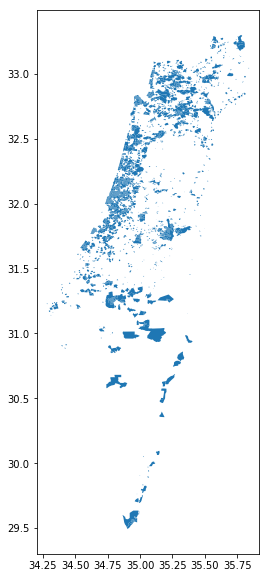

In [102]:
f, ax = plt.subplots(1, figsize=(10, 10))
ax = gpolys_merged[23].plot(ax=ax)
plt.show()

In [103]:
for election in [21, 22, 23]:
    # export file
    gpolys_merged[election].to_file(f'C:/Itay/Data/elections/output_files/gpolys_merged_{election}.geojson', driver='GeoJSON')

    # the choropleth needs the ids in a different location
    with open(f'C:/Itay/Data/elections/output_files/gpolys_merged_{election}.geojson', 'r', encoding='hebrew') as f:
        gpolys_merged_fix = json.load(f)
    for ftr in gpolys_merged_fix['features']:
        ftr['id'] = str(ftr['properties']['city_stat_id'])
    with open(f'C:/Itay/Data/elections/output_files/gpolys_merged_{election}.geojson', 'w', encoding='hebrew') as f:
        json.dump(gpolys_merged_fix, f)

## Results

In [104]:
# mapped stations
mapped = {}
for election in [21, 22, 23]:
    mapped[election] = pd.read_sql_query(f'select * from mapped_{election}', conn)

In [105]:
mapped_results = {}
for election in [21, 22]:
    mapped_results[election] = pd.merge(mapped[election], results[election], how='outer', left_on=['city_id', 'station_id'],
                                       right_on=['city_id', 'station_id'], suffixes=['_mapped', '_results'])

In [106]:
# appear in the results but not in the mapping:
for election in [21, 22]:
    print(f'Election {election}:')
    display(pd.DataFrame(mapped_results[election][mapped_results[election].city_name_mapped.isnull()] \
                         .groupby('city_name_results')['station_id'].count()))

Election 21:


,station_id
city_name_results,
אבו ג'ווייעד (שבט),3
אבו עבדון (שבט),1
אבו קורינאת (שבט),4
אבו רובייעה (שבט),6
אבו רוקייק (שבט),7
אטרש (שבט),3
אסד (שבט),1
אעצם (שבט),7
ג'נאביב (שבט),1


Election 22:


,station_id
city_name_results,
אבו ג'ווייעד (שבט),3
אבו עבדון (שבט),1
אבו קורינאת (שבט),4
אבו רובייעה (שבט),6
אבו רוקייק (שבט),7
אטרש (שבט),3
אסד (שבט),1
אעצם (שבט),7
בית שמש,1


In [107]:
# appear in the mapping but not in the results:
for election in [21, 22]:
    print(f'Election {election}:')
    display(pd.DataFrame(mapped_results[election][mapped_results[election].city_name_results.isnull()] \
                         .groupby('city_name_mapped')['station_id'].count()))

Election 21:


,station_id
city_name_mapped,


Election 22:


,station_id
city_name_mapped,
ירכא,3
סח'נין,1


In [108]:
# city name is different in the results and in the mapping
for election in [21, 22]:
    print(f'Election {election}:')
    display(pd.DataFrame(mapped_results[election][(mapped_results[election].city_name_results.notnull() &
                                                 mapped_results[election].city_name_mapped.notnull() &
                                                 (mapped_results[election].city_name_results!=mapped_results[election].city_name_mapped))] \
                         .groupby('city_name_mapped')['station_id'].count()))

Election 21:


,station_id
city_name_mapped,


Election 22:


,station_id
city_name_mapped,


In [109]:
for election in [21, 22]:
    mapped_results[election] = mapped_results[election][(mapped_results[election].city_name_results.notnull() & mapped_results[election].city_name_mapped.notnull())]

In [110]:
mapped_results[21].drop(columns=['city_id', 'city_name_mapped', 'station_id', 'center_id_mapped', 'station_address', 
                                 'station_desc', 'pop', 'voters_mapped', 'jewish_voters', 'jewish_pop',
                                 'actual_voters', 'split_type', 'static_id_mapped', 'city_center_id', 'story',
                                 'static_id_results', 'city_name_results', 'center_id_results', 'invalid'], inplace=True)
mapped_results[21].rename(columns={'voters_results': 'votes', 'אמת': 'avoda', 'ג': 'hatora', 'דעם': 'balad', 'ום': 'hadash',
                                   'ז': 'other1', 'זי': 'other2', 'זך': 'other3', 'זנ': 'other4', 'זץ': 'other9', 'טב': 'yamin',
                                   'י': 'other5', 'יז': 'other6', 'ין': 'other7', 'יץ': 'other8', 'כ': 'kulanu', 'ךק': 'other10',
                                   'ל': 'liberman', 'מחל': 'likud', 'מרצ': 'meretz', 'נ': 'other12', 'נך': 'other13', 'נץ': 'other14',
                                   'נר': 'other11', 'ן': 'other15', 'ןך': 'other16', 'ןנ': 'other17', 'פה': 'ganz', 'ףז': 'other18',
                                   'ףי': 'other19', 'ףך': 'other20', 'ףנ': 'other21', 'ףץ': 'other22', 'צק': 'other23',
                                   'ץ': 'other24', 'ץז': 'other25', 'ץי': 'other26', 'ק': 'other27', 'קי': 'other28',
                                   'קן': 'other29', 'קף': 'other30', 'ר': 'other31', 'שס': 'shas', 'נז': 'other32'}, inplace=True)
mapped_results[22].drop(columns=['city_id', 'city_name_mapped', 'station_id', 'center_id_mapped', 'station_address', 
                                 'station_desc', 'pop', 'voters_mapped', 'jewish_voters', 'jewish_pop',
                                 'actual_voters', 'split_type', 'static_id_mapped', 'city_center_id', 'story',
                                 'static_id_results', 'city_name_results', 'center_id_results', 'invalid'], inplace=True)
mapped_results[22].rename(columns={'voters_results': 'votes', 'אמת': 'avoda', 'ג': 'hatora', 'ודעם': 'hameshutefet', 
                                 'ז': 'other1', 'זכ': 'other2', 'זן': 'other3', 'זץ': 'other4', 'טב': 'yamina', 
                                 'י': 'other5', 'יז': 'other6', 'ינ': 'other7', 'יף': 'other8', 'יק': 'other9', 
                                 'כ': 'other10', 'כי': 'other11', 'כף': 'bengvir', 'ל': 'liberman', 'מחל': 
                                 'likud', 'מרצ': 'meretz', 'נ': 'other12', 'נך': 'other13', 'נץ': 'other14', 
                                 'פה': 'ganz', 'ףז': 'other15', 'צ': 'other16', 'צן': 'other17', 'ץ': 'other18',
                                 'ק': 'other19', 'קך': 'other20', 'קץ': 'other21', 'רק': 'other22', 'שס': 'shas'}, inplace=True)
# sum all the small parties under 'other'
mapped_results[21]['other'] = mapped_results[21][['other' + str(x) for x in range(1, 33)]].T.sum()
mapped_results[22]['other'] = mapped_results[22][['other' + str(x) for x in range(1, 23)]].T.sum()
mapped_results[21].drop(columns=['other' + str(x) for x in range(1, 33)], inplace=True)
mapped_results[22].drop(columns=['other' + str(x) for x in range(1, 23)], inplace=True)

In [111]:
# verify that the sum of all the parties equals the kosher votes
mapped_results[22]['sum'] = mapped_results[22][['avoda', 'hatora', 'hameshutefet', 'yamina', 'bengvir', 'liberman', 'likud', 'meretz', 'ganz', 'shas', 'other']].T.sum()
display(mapped_results[22][mapped_results[22]['sum'] != mapped_results[22].kosher])
mapped_results[21]['sum'] = mapped_results[21][['avoda', 'hatora', 'balad', 'hadash', 'yamin', 'liberman', 'likud', 'meretz', 'ganz', 'shas', 'kulanu', 'other']].T.sum()
display(mapped_results[21][mapped_results[21]['sum'] != mapped_results[21].kosher])

,city_stat_id,bzb,votes,kosher,avoda,hatora,hameshutefet,yamina,bengvir,liberman,likud,meretz,ganz,shas,other,sum


,city_stat_id,bzb,votes,kosher,avoda,hatora,balad,hadash,yamin,kulanu,liberman,likud,meretz,ganz,shas,other,sum


In [112]:
mapped_results[21].drop(columns=['sum'], inplace=True)
mapped_results[22].drop(columns=['sum'], inplace=True)

In [113]:
mapped_results[21].head(3)

,city_stat_id,bzb,votes,kosher,avoda,hatora,balad,hadash,yamin,kulanu,liberman,likud,meretz,ganz,shas,other
0,3000/821.0,527,153,149,0,108,0,0,8,0,1,2,0,0,30,0
1,3000/822.0,621,336,330,0,116,0,0,13,0,0,27,0,3,168,3
2,3000/532.0,478,340,335,0,113,0,0,4,0,0,36,0,0,179,3


In [114]:
mapped_results[22].head(3)

,city_stat_id,bzb,votes,kosher,avoda,hatora,hameshutefet,yamina,bengvir,liberman,likud,meretz,ganz,shas,other
0,3000/821.0,531.0,167.0,162.0,0.0,113.0,0.0,0.0,8.0,1.0,2.0,3.0,1.0,34.0,0.0
1,3000/822.0,636.0,361.0,359.0,0.0,135.0,0.0,3.0,13.0,0.0,19.0,0.0,3.0,185.0,1.0
2,3000/532.0,481.0,338.0,335.0,0.0,111.0,0.0,3.0,7.0,0.0,24.0,0.0,4.0,186.0,0.0


In [115]:
results_by_polygon = {}
for election in [21, 22]:
    # group the results by polygon
    results_by_polygon[election] = mapped_results[election].groupby('city_stat_id').sum()

    # fix the index
    results_by_polygon[election].index = results_by_polygon[election].index.map(lambda x: x.replace('+', ','))

In [116]:
# translate the number of votes for each party to percentage of the total
for mif in ['avoda', 'hatora', 'balad', 'hadash', 'yamin', 'kulanu', 'liberman', 'likud', 'meretz', 'ganz', 'shas', 'other']:
    results_by_polygon[21][mif] = results_by_polygon[21][mif] / results_by_polygon[21]['kosher'] / 100
for mif in ['avoda', 'hatora', 'hameshutefet', 'yamina', 'bengvir', 'liberman', 'likud', 'meretz', 'ganz', 'shas', 'other']:
    results_by_polygon[22][mif] = results_by_polygon[22][mif] / results_by_polygon[22]['kosher'] / 100

# translate the total votes to turnout
results_by_polygon[21]['votes'] = results_by_polygon[21]['votes'] / results_by_polygon[21]['bzb']
results_by_polygon[22]['votes'] = results_by_polygon[22]['votes'] / results_by_polygon[22]['bzb']

# determine the polygon's winner and its result
results_by_polygon[21]['winner'] = \
    results_by_polygon[21][['avoda', 'hatora', 'balad', 'hadash', 'yamin', 'kulanu', 'liberman', 'likud', 'meretz', 'ganz', 'shas', 'other']] \
        .T.apply(lambda x: x.idxmax())
results_by_polygon[21]['winner_result'] = \
    results_by_polygon[21][['avoda', 'hatora', 'balad', 'hadash', 'yamin', 'kulanu', 'liberman', 'likud', 'meretz', 'ganz', 'shas', 'other']].T.max() * 100

results_by_polygon[22]['winner'] = \
    results_by_polygon[22][['avoda', 'hatora', 'hameshutefet', 'yamina', 'bengvir', 'liberman', 'likud', 'meretz', 'ganz', 'shas', 'other']] \
        .T.apply(lambda x: x.idxmax())
results_by_polygon[22]['winner_result'] = \
    results_by_polygon[22][['avoda', 'hatora', 'hameshutefet', 'yamina', 'bengvir', 'liberman', 'likud', 'meretz', 'ganz', 'shas', 'other']].T.max() * 100

In [117]:
joined21 = gpolys_merged[21].set_index('city_stat_id').join(results_by_polygon[21], how='outer')
joined21[joined21.geometry.isnull()]

,geometry,city_name,city_name_lat,bzb,votes,kosher,avoda,hatora,balad,hadash,yamin,kulanu,liberman,likud,meretz,ganz,shas,other,winner,winner_result
city_stat_id,,,,,,,,,,,,,,,,,,,,
1243/1.0,None,NaN,NaN,2191,0.707896,1549,0.001246,0.000026,0.000019,0.000084,0.000065,0.000426,0.000452,0.001511,0.000768,0.004500,0.000052,0.000852,ganz,0.449968
3744/1.0,None,NaN,NaN,427,0.901639,384,0.000000,0.000026,0.000000,0.000000,0.006536,0.000026,0.000000,0.000833,0.000000,0.000026,0.000130,0.002422,yamin,0.653646
3777/1.0,None,NaN,NaN,204,0.911765,186,0.000054,0.000000,0.000000,0.000000,0.002957,0.000161,0.000000,0.001129,0.000000,0.000323,0.000000,0.005376,other,0.537634
3822/1.0,None,NaN,NaN,303,0.914191,277,0.000000,0.000036,0.000000,0.000000,0.005451,0.000036,0.000000,0.000830,0.000000,0.000000,0.000036,0.003610,yamin,0.545126
3823/1.0,None,NaN,NaN,1825,0.784110,1420,0.000014,0.000817,0.000000,0.000000,0.001944,0.000070,0.000021,0.001937,0.000007,0.000063,0.004000,0.001127,shas,0.400000
3824/1.0,None,NaN,NaN,65,0.984615,64,0.000000,0.000000,0.000000,0.000000,0.007656,0.000000,0.000000,0.000469,0.000000,0.000000,0.000156,0.001719,yamin,0.765625


In [118]:
joined21[joined21.bzb.isnull()]

,geometry,city_name,city_name_lat,bzb,votes,kosher,avoda,hatora,balad,hadash,yamin,kulanu,liberman,likud,meretz,ganz,shas,other,winner,winner_result


In [119]:
# these appear in the results and in the mapping but not in the geo file:
bet_pre_balancing[21][bet_pre_balancing[21].city_stat_id.isin(joined21[joined21.geometry.isnull()].index)]

,city_id,station_id,city_name,center_id,station_address,station_desc,pop,voters,jewish_voters,jewish_pop,actual_voters,city_center_id,stat_id,city_stat_id,city_stats_id_concat,n_concatenated
1168,3824,1.0,עמיחי,1,עמיחי,מזכירות,214,65,65,214,65,3824/1,1.0,3824/1.0,NaN,0
4337,1243,1.0,קציר,1,"שד האמירים,55","בי""ס יסודי קציר","1,142",791,739,"1,069",791,1243/1,1.0,1243/1.0,1243/1.0,1
4338,1243,2.0,קציר,3,"האלה,29",מועדון נוער,397,266,235,352,266,1243/3,1.0,1243/1.0,1243/1.0,1
4339,1243,3.0,קציר,2,"הארז,1",מועדון פיס לגיל הזהב,843,604,504,711,604,1243/2,1.0,1243/1.0,1243/1.0,1
4340,1243,4.0,קציר,1,"שד האמירים,55","בי""ס יסודי קציר",725,530,482,658,530,1243/1,1.0,1243/1.0,1243/1.0,1
5516,3823,1.0,גני מודיעין,1,"רמ""א,8","בי""ס חינוך עצמאי-גני מודיעין","1,313",668,668,"1,308",668,3823/1,1.0,3823/1.0,NaN,0
5517,3823,2.0,גני מודיעין,1,"רמ""א,8","בי""ס חינוך עצמאי-גני מודיעין","1,027",603,597,"1,015",603,3823/1,1.0,3823/1.0,NaN,0
5518,3823,3.0,גני מודיעין,1,"רמ""א,8","בי""ס חינוך עצמאי-גני מודיעין",984,554,551,976,554,3823/1,1.0,3823/1.0,NaN,0
10152,3777,1.0,סנסנה,1,סנסנה,ספרית בן-דור,524,204,204,524,204,3777/1,1.0,3777/1.0,NaN,0
10410,3744,1.0,ברוכין,1,ברוכין,מועדון הישוב,"1,171",427,423,"1,150",427,3744/1,1.0,3744/1.0,NaN,0


In [120]:
joined22 = gpolys_merged[22].set_index('city_stat_id').join(results_by_polygon[22], how='outer')
joined22[joined22.geometry.isnull()]

,geometry,city_name,city_name_lat,bzb,votes,kosher,avoda,hatora,hameshutefet,yamina,bengvir,liberman,likud,meretz,ganz,shas,other,winner,winner_result
city_stat_id,,,,,,,,,,,,,,,,,,,
1243/1.0,None,NaN,NaN,2224.0,0.698741,1552.0,0.001089,0.000045,0.000187,0.000290,0.000077,0.000851,0.001572,0.001302,0.004439,0.000077,0.000071,ganz,0.443943
3744/1.0,None,NaN,NaN,437.0,0.885584,387.0,0.000000,0.000181,0.000000,0.007881,0.000775,0.000078,0.000827,0.000000,0.000103,0.000129,0.000026,yamina,0.788114
3777/1.0,None,NaN,NaN,241.0,0.875519,211.0,0.000142,0.000142,0.000000,0.008246,0.000284,0.000000,0.000758,0.000000,0.000284,0.000095,0.000047,yamina,0.824645
3822/1.0,None,NaN,NaN,313.0,0.904153,283.0,0.000071,0.000106,0.000000,0.007915,0.001201,0.000000,0.000636,0.000000,0.000035,0.000035,0.000000,yamina,0.791519
3823/1.0,None,NaN,NaN,1862.0,0.793233,1469.0,0.000020,0.000817,0.000000,0.001484,0.001246,0.000054,0.001729,0.000020,0.000102,0.004506,0.000020,shas,0.450647
3824/1.0,None,NaN,NaN,71.0,0.957746,68.0,0.000000,0.000294,0.000147,0.002647,0.003971,0.000000,0.001324,0.000000,0.000147,0.001471,0.000000,bengvir,0.397059


In [121]:
joined22[joined22.bzb.isnull()]

,geometry,city_name,city_name_lat,bzb,votes,kosher,avoda,hatora,hameshutefet,yamina,bengvir,liberman,likud,meretz,ganz,shas,other,winner,winner_result


In [122]:
# these appear in the results and in the mapping but not in the geo file:
bet_pre_balancing[22][bet_pre_balancing[22].city_stat_id.isin(joined22[joined22.geometry.isnull()].index)]

,city_id,station_id,city_name,center_id,station_address,station_desc,pop,voters,jewish_voters,jewish_pop,actual_voters,city_center_id,stat_id,city_stat_id,city_stats_id_concat,n_concatenated
1136,3824,1.0,עמיחי,1,עמיחי,מזכירות,216,71,71,216,71,3824/1,1.0,3824/1.0,NaN,0
4244,1243,1.0,קציר,1,"שד האמירים,55","בי""ס יסודי קציר","1,156",803,753,"1,087",803,1243/1,1.0,1243/1.0,1243/1.0,1
4245,1243,2.0,קציר,3,"האלה,29",מועדון נוער,400,271,237,347,271,1243/3,1.0,1243/1.0,1243/1.0,1
4246,1243,3.0,קציר,2,"הארז,1",מועדון פיס לגיל הזהב,839,607,506,708,607,1243/2,1.0,1243/1.0,1243/1.0,1
4247,1243,4.0,קציר,1,"שד האמירים,55","בי""ס יסודי קציר",734,543,491,662,543,1243/1,1.0,1243/1.0,1243/1.0,1
5421,3823,1.0,גני מודיעין,1,"רמ""א,8","בי""ס חינוך עצמאי-גני מודיעין","1,345",680,680,"1,340",680,3823/1,1.0,3823/1.0,NaN,0
5422,3823,2.0,גני מודיעין,1,"רמ""א,8","בי""ס חינוך עצמאי-גני מודיעין","1,073",625,617,"1,057",625,3823/1,1.0,3823/1.0,NaN,0
5423,3823,3.0,גני מודיעין,1,"רמ""א,8","בי""ס חינוך עצמאי-גני מודיעין",976,557,554,968,557,3823/1,1.0,3823/1.0,NaN,0
9980,3777,1.0,סנסנה,1,סנסנה,ספרית בן-דור,589,241,241,589,241,3777/1,1.0,3777/1.0,NaN,0
10230,3744,1.0,ברוכין,1,ברוכין,מועדון הישוב,"1,204",437,433,"1,188",437,3744/1,1.0,3744/1.0,NaN,0


In [123]:
results_by_polygon[21].drop(index=joined21[joined21.geometry.isnull()].index, inplace=True)

In [124]:
results_by_polygon[22].drop(index=joined22[joined22.geometry.isnull()].index, inplace=True)

In [125]:
# verify that we have exactly as many results by polygon as in the geo file
len(gpolys_merged[22]) == len(results_by_polygon[22])

True

In [126]:
results_by_polygon[21].head(4)

,bzb,votes,kosher,avoda,hatora,balad,hadash,yamin,kulanu,liberman,likud,meretz,ganz,shas,other,winner,winner_result
city_stat_id,,,,,,,,,,,,,,,,,
10/1.0,333,0.711712,235,0.000170,0.000128,0.000000,0.000000,0.000426,0.000383,0.000000,0.005277,0.000043,0.000213,0.003106,0.000255,likud,0.527660
1015/1.0,2347,0.787388,1847,0.000937,0.000022,0.000000,0.000011,0.000087,0.000395,0.000135,0.002512,0.000612,0.004256,0.000135,0.000899,ganz,0.425555
1015/2.0,4870,0.722793,3507,0.000613,0.000108,0.000003,0.000017,0.000687,0.000399,0.000046,0.003867,0.000550,0.002498,0.000351,0.000861,likud,0.386655
1015/3.0,3305,0.771861,2543,0.000908,0.000028,0.000000,0.000016,0.000090,0.000342,0.000087,0.002540,0.000845,0.004231,0.000122,0.000790,ganz,0.423122


In [127]:
for election in [21, 22]:
    # add the city name from the polygons file
    results_by_polygon[election] = results_by_polygon[election].join(gpolys_merged[election].set_index('city_stat_id')[['city_name', 'city_name_lat']])
    
    # add a column that determines if the polygon covers the whole city or just part, for the hover text
    results_by_polygon[election] = pd.merge(results_by_polygon[election], pd.DataFrame(results_by_polygon[election].groupby('city_name').count()['winner']),
                                             how='left', left_on='city_name', right_index=True, suffixes=['', '_cnt'])
    results_by_polygon[election]['has_parts'] = results_by_polygon[election]['winner_cnt'].apply(lambda x: True if x > 1 else False)
    results_by_polygon[election].drop(columns=['winner_cnt'], inplace=True)
    
    # set 'id' as a column so it appears in the csv
    results_by_polygon[election].index.rename('id', inplace=True)
    results_by_polygon[election].reset_index(inplace=True)

In [128]:
results_by_polygon[21].head(5)

,id,bzb,votes,kosher,avoda,hatora,balad,hadash,yamin,kulanu,...,likud,meretz,ganz,shas,other,winner,winner_result,city_name,city_name_lat,has_parts
0,10/1.0,333,0.711712,235,0.000170,0.000128,0.000000,0.000000,0.000426,0.000383,...,0.005277,0.000043,0.000213,0.003106,0.000255,likud,0.527660,תירוש,TIROSH,False
1,1015/1.0,2347,0.787388,1847,0.000937,0.000022,0.000000,0.000011,0.000087,0.000395,...,0.002512,0.000612,0.004256,0.000135,0.000899,ganz,0.425555,מבשרת ציון,MEVASSERET ZIYYON,True
2,1015/2.0,4870,0.722793,3507,0.000613,0.000108,0.000003,0.000017,0.000687,0.000399,...,0.003867,0.000550,0.002498,0.000351,0.000861,likud,0.386655,מבשרת ציון,MEVASSERET ZIYYON,True
3,1015/3.0,3305,0.771861,2543,0.000908,0.000028,0.000000,0.000016,0.000090,0.000342,...,0.002540,0.000845,0.004231,0.000122,0.000790,ganz,0.423122,מבשרת ציון,MEVASSERET ZIYYON,True
4,1015/4.0,2092,0.640535,1339,0.001068,0.000030,0.000015,0.000022,0.000142,0.000306,...,0.002211,0.001120,0.004182,0.000090,0.000769,ganz,0.418223,מבשרת ציון,MEVASSERET ZIYYON,True


In [129]:
for col21 in ['avoda', 'hatora', 'balad', 'hadash', 'yamin', 'kulanu', 'liberman', 'likud', 'meretz', 'ganz', 'shas', 'other']:
    results_by_polygon[21][col21] = results_by_polygon[21][col21].apply(lambda x: round(x*100, 2))
for col22 in ['avoda', 'hatora', 'hameshutefet', 'yamina', 'bengvir', 'liberman', 'likud', 'meretz', 'ganz', 'shas', 'other']:
    results_by_polygon[22][col22] = results_by_polygon[22][col22].apply(lambda x: round(x*100, 2))
results_by_polygon[21]['winner_result'] = results_by_polygon[21]['winner_result'].apply(lambda x: round(x, 2))
results_by_polygon[22]['winner_result'] = results_by_polygon[22]['winner_result'].apply(lambda x: round(x, 2))

In [130]:
# parties dictionary is used for the color-coding
parties_21 = {
    'other': {'label': 'מפלגה קטנה', 'color': 'rgb(125, 121, 121)', 'value': 0.08, 'final': 0.9},
    'kulanu': {'label': 'עוצמה יהודית', 'color': 'rgb(235, 128, 52)', 'value': 0.16, 'final': 1.9},
    'meretz': {'label': 'המחנה הדמוקרטי', 'color': 'rgb(31, 128, 29)', 'value': 0.24, 'final': 4.3},
    'avoda': {'label': 'העבודה-גשר', 'color': 'rgb(250, 60, 35)', 'value': 0.32, 'final': 4.8},
    'yamin': {'label': 'ימינה', 'color': 'rgb(35, 250, 189)', 'value': 0.4, 'final': 5.9},
    'hatora': {'label': 'יהדות התורה', 'color': 'rgb(160, 250, 35)', 'value': 0.48, 'final': 6.1},
    'liberman': {'label': 'ישראל ביתנו', 'color': 'rgb(255, 170, 0)', 'value': 0.56, 'final': 7.0},
    'shas': {'label': 'ש"ס', 'color': 'rgb(161, 8, 161)', 'value': 0.64, 'final': 7.4},
    'balad': {'label': 'הרשימה המשותפת', 'color': 'rgb(214, 71, 92)', 'value': 0.72, 'final': 10.6},
    'hadash': {'label': 'הרשימה המשותפת', 'color': 'rgb(143, 44, 59)', 'value': 0.80, 'final': 10.6},
    'likud': {'label': 'הליכוד', 'color': 'rgb(13, 161, 214)', 'value': 0.88, 'final': 25.1},
    'ganz': {'label': 'כחול לבן', 'color': 'rgb(36, 8, 161)', 'value': 0.96, 'final': 26.0}
}
parties_22 = {
    'other': {'label': 'אחר', 'color': 'rgb(125, 121, 121)', 'value': 0.09},
    'bengvir': {'label': 'עוצמה יהודית', 'color': 'rgb(130, 29, 29)', 'value': 0.18},
    'meretz': {'label': 'המחנה הדמוקרטי', 'color': 'rgb(31, 128, 29)', 'value': 0.27},
    'avoda': {'label': 'העבודה-גשר', 'color': 'rgb(250, 60, 35)', 'value': 0.36},
    'yamina': {'label': 'ימינה', 'color': 'rgb(35, 250, 189)', 'value': 0.45},
    'hatora': {'label': 'יהדות התורה', 'color': 'rgb(160, 250, 35)', 'value': 0.54},
    'liberman': {'label': 'ישראל ביתנו', 'color': 'rgb(255, 170, 0)', 'value': 0.63},
    'shas': {'label': 'ש"ס', 'color': 'rgb(161, 8, 161)', 'value': 0.72},
    'hameshutefet': {'label': 'הרשימה המשותפת', 'color': 'rgb(161, 8, 31)', 'value': 0.81},
    'likud': {'label': 'הליכוד', 'color': 'rgb(3, 186, 252)', 'value': 0.90},
    'ganz': {'label': 'כחול לבן', 'color': 'rgb(36, 8, 161)', 'value': 0.99}
}

In [131]:
cs_21 = []
for x in parties_21:
    cs_21.append([parties_21[x]['value']-0.07, parties_21[x]['color']])
    cs_21.append([parties_21[x]['value']+0.0001, parties_21[x]['color']])
cs_21.append([1, parties_21[x]['color']])
cs_21[0][0] = 0

cs_22 = []
for x in parties_22:
    cs_22.append([parties_22[x]['value']-0.08, parties_22[x]['color']])
    cs_22.append([parties_22[x]['value']+0.0001, parties_22[x]['color']])
cs_22.append([1, parties_22[x]['color']])
cs_22[0][0] = 0

In [132]:
cs_21

[[0, 'rgb(125, 121, 121)'],
 [0.0801, 'rgb(125, 121, 121)'],
 [0.09, 'rgb(235, 128, 52)'],
 [0.1601, 'rgb(235, 128, 52)'],
 [0.16999999999999998, 'rgb(31, 128, 29)'],
 [0.24009999999999998, 'rgb(31, 128, 29)'],
 [0.25, 'rgb(250, 60, 35)'],
 [0.3201, 'rgb(250, 60, 35)'],
 [0.33, 'rgb(35, 250, 189)'],
 [0.4001, 'rgb(35, 250, 189)'],
 [0.41, 'rgb(160, 250, 35)'],
 [0.48009999999999997, 'rgb(160, 250, 35)'],
 [0.49000000000000005, 'rgb(255, 170, 0)'],
 [0.5601, 'rgb(255, 170, 0)'],
 [0.5700000000000001, 'rgb(161, 8, 161)'],
 [0.6401, 'rgb(161, 8, 161)'],
 [0.6499999999999999, 'rgb(214, 71, 92)'],
 [0.7201, 'rgb(214, 71, 92)'],
 [0.73, 'rgb(143, 44, 59)'],
 [0.8001, 'rgb(143, 44, 59)'],
 [0.81, 'rgb(13, 161, 214)'],
 [0.8801, 'rgb(13, 161, 214)'],
 [0.8899999999999999, 'rgb(36, 8, 161)'],
 [0.9601, 'rgb(36, 8, 161)'],
 [1, 'rgb(36, 8, 161)']]

In [133]:
cs_22

[[0, 'rgb(125, 121, 121)'],
 [0.0901, 'rgb(125, 121, 121)'],
 [0.09999999999999999, 'rgb(130, 29, 29)'],
 [0.18009999999999998, 'rgb(130, 29, 29)'],
 [0.19, 'rgb(31, 128, 29)'],
 [0.2701, 'rgb(31, 128, 29)'],
 [0.27999999999999997, 'rgb(250, 60, 35)'],
 [0.3601, 'rgb(250, 60, 35)'],
 [0.37, 'rgb(35, 250, 189)'],
 [0.4501, 'rgb(35, 250, 189)'],
 [0.46, 'rgb(160, 250, 35)'],
 [0.5401, 'rgb(160, 250, 35)'],
 [0.55, 'rgb(255, 170, 0)'],
 [0.6301, 'rgb(255, 170, 0)'],
 [0.64, 'rgb(161, 8, 161)'],
 [0.7201, 'rgb(161, 8, 161)'],
 [0.7300000000000001, 'rgb(161, 8, 31)'],
 [0.8101, 'rgb(161, 8, 31)'],
 [0.8200000000000001, 'rgb(3, 186, 252)'],
 [0.9001, 'rgb(3, 186, 252)'],
 [0.91, 'rgb(36, 8, 161)'],
 [0.9901, 'rgb(36, 8, 161)'],
 [1, 'rgb(36, 8, 161)']]

In [134]:
# translate the winner to the numeric value of the party
results_by_polygon[21]['winner'] = results_by_polygon[21]['winner'].apply(lambda x: parties_21[x]['value'])
results_by_polygon[22]['winner'] = results_by_polygon[22]['winner'].apply(lambda x: parties_22[x]['value'])
results_by_polygon[21].head()

,id,bzb,votes,kosher,avoda,hatora,balad,hadash,yamin,kulanu,...,likud,meretz,ganz,shas,other,winner,winner_result,city_name,city_name_lat,has_parts
0,10/1.0,333,0.711712,235,0.02,0.01,0.0,0.0,0.04,0.04,...,0.53,0.00,0.02,0.31,0.03,0.88,0.53,תירוש,TIROSH,False
1,1015/1.0,2347,0.787388,1847,0.09,0.00,0.0,0.0,0.01,0.04,...,0.25,0.06,0.43,0.01,0.09,0.96,0.43,מבשרת ציון,MEVASSERET ZIYYON,True
2,1015/2.0,4870,0.722793,3507,0.06,0.01,0.0,0.0,0.07,0.04,...,0.39,0.06,0.25,0.04,0.09,0.88,0.39,מבשרת ציון,MEVASSERET ZIYYON,True
3,1015/3.0,3305,0.771861,2543,0.09,0.00,0.0,0.0,0.01,0.03,...,0.25,0.08,0.42,0.01,0.08,0.96,0.42,מבשרת ציון,MEVASSERET ZIYYON,True
4,1015/4.0,2092,0.640535,1339,0.11,0.00,0.0,0.0,0.01,0.03,...,0.22,0.11,0.42,0.01,0.08,0.96,0.42,מבשרת ציון,MEVASSERET ZIYYON,True


In [135]:
# export
results_by_polygon[21].to_csv('C:/Itay/Data/elections/output_files/results_by_polygon_21.csv')
results_by_polygon[22].to_csv('C:/Itay/Data/elections/output_files/results_by_polygon_22.csv')

# Merge the merged

In [136]:
from functools import reduce

In [137]:
dfs = [gpolys_merged[x][['city_stat_id', 'city_name_lat']].rename(columns={'city_name_lat': f'city_{x}'}) for x in [23, 22, 21]]

In [138]:
gpolys_all = reduce((lambda left, right: pd.merge(left, right, how='outer', left_on='city_stat_id', right_on='city_stat_id')), dfs)

In [141]:
gpolys_all[gpolys_all.city_stat_id.str.startswith('1031')]

,city_stat_id,city_23,city_22,city_21
15,"1031/1.0,1031/3.0,1031/5.0",SEDEROT,NaN,NaN
16,1031/2.0,SEDEROT,SEDEROT,SEDEROT
17,1031/4.0,SEDEROT,SEDEROT,SEDEROT
18,1031/6.0,SEDEROT,SEDEROT,SEDEROT
19,1031/7.0,SEDEROT,SEDEROT,SEDEROT
2409,1031/3.0,NaN,SEDEROT,SEDEROT
2410,1031/5.0,NaN,SEDEROT,SEDEROT


In [142]:
gpolys_mismatch = gpolys_all[gpolys_all.city_23.isnull() | gpolys_all.city_22.isnull() | gpolys_all.city_21.isnull()]

In [1051]:
pd.set_option('display.max_rows', 490)
pd.set_option('display.max_colwidth', 490)

In [143]:
len(gpolys_mismatch)

430

In [148]:
gpolys_mismatch_input = pd.concat(
    [gpolys_mismatch[gpolys_mismatch[f'city_{e}'].notnull()].assign(csi=gpolys_mismatch.city_stat_id.str.split(','))[['csi', 'city_stat_id']] for e in [21, 22, 23]]
)    

In [150]:
gpolys_mismatch_input.explode('csi')

AttributeError: 'DataFrame' object has no attribute 'explode'

In [180]:
bet_pre_balancing['COMBINED'] = pd.concat(bet_pre_balancing)

In [181]:
bet_final['COMBINED'] = pd.concat(bet_final)

TypeError: '<' not supported between instances of 'str' and 'int'

In [182]:
entity_table = {}
combi_stats = {}
for election in [21, 22, 23, 'COMBINED']:
    print(f'\n== Election {election} ==\n')
    # merging using SQL
    conn.execute('drop table if exists pre')
    conn.execute('drop table if exists final')
    bet_pre_balancing[election].to_sql('pre', conn, index=False)
    bet_final[election].to_sql('final', conn, index=False)

    # combi_stats: all city_stats_id affected by balanced stations (stable); linking_table is identical and will be modified
    o = conn.execute('drop table if exists combi_stats')
    q = '''
        create table combi_stats as
        select a.city_stat_id, a.city_center_id
        from pre a 
        join final b on a.city_center_id = b.city_center_id 
        where b.split_type = 'balancing' and a.stat_id is not null
        group by 1, 2
    '''
    o = conn.execute(q)
    o = conn.execute('drop table if exists linking_table')
    q = '''
        create table linking_table as
        select city_stat_id entity_id, city_stat_id, city_center_id from combi_stats
    '''
    o = conn.execute(q)
    
    # the merging loop stops when between one merging and the next the number of entities remained unchanged
    n = 0
    n_entities = 1
    new_n_entities = 0
    while new_n_entities != n_entities:
        n_entities = len(pd.read_sql_query('select * from linking_table', conn)['entity_id'].unique())
        o = conn.execute('drop table if exists linking_hop')
        q = '''
            create table linking_hop as
            select a.entity_id, a.city_stat_id, b.city_stat_id linked_id
            from linking_table a
            join linking_table b on a.city_center_id = b.city_center_id 
                and b.entity_id >= a.entity_id
            group by 1, 2, 3
        '''
        o = conn.execute(q)
        o = conn.execute('drop table if exists linking_table')
        q = '''
            create table linking_table as
            select min(entity_id) entity_id, linked_id city_stat_id, b.city_center_id
            from linking_hop a
            join combi_stats b on a.linked_id = b.city_stat_id
            group by 2, 3
        '''
        o = conn.execute(q)
        new_n_entities = len(pd.read_sql_query('select * from linking_table', conn)['entity_id'].unique())
        print(f'Finished hop {n}: started with {n_entities} entities, finished with {new_n_entities}')
        n = n + 1
        
        entity_table[election] = pd.read_sql_query('select entity_id, city_stat_id from linking_table group by 1, 2', conn)
        combi_stats[election] = pd.read_sql_query('select * from combi_stats', conn)


== Election 21 ==

Finished hop 0: started with 624 entities, finished with 310
Finished hop 1: started with 310 entities, finished with 279
Finished hop 2: started with 279 entities, finished with 271
Finished hop 3: started with 271 entities, finished with 269
Finished hop 4: started with 269 entities, finished with 269

== Election 22 ==

Finished hop 0: started with 650 entities, finished with 330
Finished hop 1: started with 330 entities, finished with 298
Finished hop 2: started with 298 entities, finished with 291
Finished hop 3: started with 291 entities, finished with 290
Finished hop 4: started with 290 entities, finished with 290

== Election 23 ==

Finished hop 0: started with 613 entities, finished with 299
Finished hop 1: started with 299 entities, finished with 269
Finished hop 2: started with 269 entities, finished with 260
Finished hop 3: started with 260 entities, finished with 258
Finished hop 4: started with 258 entities, finished with 258

== Election COMBINED ==


In [183]:
for election in [21, 22, 23, 'COMBINED']:
    display(entity_table[election].head(3))
    
    print('No areas were lost in the merging process: ', end='')
    print(len(entity_table[election]) == len(combi_stats[election]['city_stat_id'].unique()))

,entity_id,city_stat_id
0,1020/4.0,1020/4.0
1,1020/4.0,1020/5.0
2,1034/3.0,1034/3.0


No areas were lost in the merging process: True


,entity_id,city_stat_id
0,1015/3.0,1015/3.0
1,1020/4.0,1020/4.0
2,1020/4.0,1020/5.0


No areas were lost in the merging process: True


,entity_id,city_stat_id
0,1015/3.0,1015/3.0
1,1031/1.0,1031/1.0
2,1031/1.0,1031/3.0


No areas were lost in the merging process: True


,entity_id,city_stat_id
0,1015/3.0,1015/3.0
1,1020/4.0,1020/4.0
2,1020/4.0,1020/5.0


No areas were lost in the merging process: True


In [184]:
# entity_table mapps a statistical area (city_stats_id) to the unique id of the merged area, 
# a concatenation of all the city_stats_ids within it
for election in [21, 22, 23, 'COMBINED']:
    entity_table[election] = pd.merge(entity_table[election], 
        pd.DataFrame(entity_table[election].groupby('entity_id').apply(lambda x: ','.join(x.city_stat_id))),
        how='left', left_on='entity_id', right_index=True).rename(columns={0: 'city_stats_id_concat'})
    
    display(entity_table[election].head(3))

,entity_id,city_stat_id,city_stats_id_concat
0,1020/4.0,1020/4.0,"1020/4.0,1020/5.0"
1,1020/4.0,1020/5.0,"1020/4.0,1020/5.0"
2,1034/3.0,1034/3.0,"1034/3.0,1034/4.0,1034/5.0,1034/8.0"


,entity_id,city_stat_id,city_stats_id_concat
0,1015/3.0,1015/3.0,1015/3.0
1,1020/4.0,1020/4.0,"1020/4.0,1020/5.0"
2,1020/4.0,1020/5.0,"1020/4.0,1020/5.0"


,entity_id,city_stat_id,city_stats_id_concat
0,1015/3.0,1015/3.0,1015/3.0
1,1031/1.0,1031/1.0,"1031/1.0,1031/3.0,1031/5.0"
2,1031/1.0,1031/3.0,"1031/1.0,1031/3.0,1031/5.0"


,entity_id,city_stat_id,city_stats_id_concat
0,1015/3.0,1015/3.0,1015/3.0
1,1020/4.0,1020/4.0,"1020/4.0,1020/5.0"
2,1020/4.0,1020/5.0,"1020/4.0,1020/5.0"


In [164]:
entity_table[21][entity_table[21].entity_id.str.contains('1034/')]

,entity_id,city_stat_id,city_stats_id_concat
2,1034/3.0,1034/3.0,"1034/3.0,1034/4.0,1034/5.0,1034/8.0"
3,1034/3.0,1034/4.0,"1034/3.0,1034/4.0,1034/5.0,1034/8.0"
4,1034/3.0,1034/5.0,"1034/3.0,1034/4.0,1034/5.0,1034/8.0"
5,1034/3.0,1034/8.0,"1034/3.0,1034/4.0,1034/5.0,1034/8.0"


In [165]:
entity_table[22][entity_table[22].entity_id.str.contains('1034/')]

,entity_id,city_stat_id,city_stats_id_concat
4,1034/3.0,1034/3.0,"1034/3.0,1034/4.0,1034/5.0,1034/8.0"
5,1034/3.0,1034/4.0,"1034/3.0,1034/4.0,1034/5.0,1034/8.0"
6,1034/3.0,1034/5.0,"1034/3.0,1034/4.0,1034/5.0,1034/8.0"
7,1034/3.0,1034/8.0,"1034/3.0,1034/4.0,1034/5.0,1034/8.0"


In [166]:
entity_table[23][entity_table[23].entity_id.str.contains('1034/')]

,entity_id,city_stat_id,city_stats_id_concat
5,1034/3.0,1034/3.0,"1034/3.0,1034/4.0,1034/5.0"
6,1034/3.0,1034/4.0,"1034/3.0,1034/4.0,1034/5.0"
7,1034/3.0,1034/5.0,"1034/3.0,1034/4.0,1034/5.0"


In [167]:
entity_table['COMBINED'][entity_table['COMBINED'].entity_id.str.contains('1034/')]

,entity_id,city_stat_id,city_stats_id_concat
7,1034/3.0,1034/3.0,"1034/3.0,1034/4.0,1034/5.0,1034/8.0"
8,1034/3.0,1034/4.0,"1034/3.0,1034/4.0,1034/5.0,1034/8.0"
9,1034/3.0,1034/5.0,"1034/3.0,1034/4.0,1034/5.0,1034/8.0"
10,1034/3.0,1034/8.0,"1034/3.0,1034/4.0,1034/5.0,1034/8.0"


In [192]:
bet_pre_balancing_united = {}
for election in [21, 22, 23]:
    # add the ids of the merged area to the original table
    bet_pre_balancing_united[election] = pd.merge(bet_pre_balancing[election], 
                                           entity_table['COMBINED'][['city_stat_id', 'city_stats_id_concat']], how='left',
                                           left_on='city_stat_id', right_on='city_stat_id')

    # n_concatenated is the number of _original_ areas within the final merged area
    bet_pre_balancing_united[election]['n_concatenated'] = bet_pre_balancing_united[election]['city_stats_id_concat'] \
        .apply(lambda x: len(x.split(',')) if not pd.isna(x) else 0)

In [1052]:
gpolys_mismatch.sort_values('city_stat_id')

,city_stat_id,city_23,city_22,city_21
11,1020/4.0,OR AQIVA,NaN,NaN
2408,"1020/4.0,1020/5.0",NaN,OR AQIVA,OR AQIVA
12,1020/5.0,OR AQIVA,NaN,NaN
15,"1031/1.0,1031/3.0,1031/5.0",SEDEROT,NaN,NaN
2409,1031/3.0,NaN,SEDEROT,SEDEROT
2410,1031/5.0,NaN,SEDEROT,SEDEROT
22,"1034/3.0,1034/4.0,1034/5.0",QIRYAT MAL'AKHI,NaN,NaN
2411,"1034/3.0,1034/4.0,1034/5.0,1034/8.0",NaN,QIRYAT MAL'AKHI,QIRYAT MAL'AKHI
25,1034/8.0,QIRYAT MAL'AKHI,NaN,NaN
57,1063/4.0,MA'ALOT-TARSHIHA,NaN,MA'ALOT-TARSHIHA


In [1004]:
entity_table[23].head(3)

,entity_id,city_stat_id,city_stats_id_concat
0,1015/3.0,1015/3.0,1015/3.0
1,1031/1.0,1031/1.0,"1031/1.0,1031/3.0,1031/5.0"
2,1031/1.0,1031/3.0,"1031/1.0,1031/3.0,1031/5.0"


In [1002]:
len(entity_table[23])

613